# Customer Churn Prediction: From Risk Scores to Retention Actions

## 1. Project Overview

This notebook is a concise portfolio reconstruction of a more detailed master-reference notebook. It reproduces the same customer-churn modeling workflow using cleaner organization, shorter code, and modern Python and scikit-learn APIs.

The original master notebook remains unchanged and serves as the detailed technical record for this project.

The feature contract, development/test split, selected model family, hyperparameters, calibration decision, and operating thresholds were locked during the original development process. Therefore, this notebook is a **reproduction of a previously completed workflow**, not a second independent validation experiment.

### 1.1 Project Objective

The goal is to predict which customers are at elevated risk of churn and translate those probabilities into practical retention actions.

The project emphasizes:

* leakage-aware feature selection;
* honest development and final-test separation;
* preprocessing inside model pipelines;
* comparison with strong simple baselines;
* PR-AUC as the primary model-selection metric;
* cross-validation and stability analysis;
* out-of-fold threshold selection;
* probability calibration;
* retention capacity and workload trade-offs;
* responsible model interpretation;
* deployment validation and monitoring.

The final model produces churn probabilities. Decisions such as priority calls, lower-cost email outreach, or no immediate action are treated as a separate business-policy layer.

### 1.2 Reproduction and Evaluation Policy

Several safeguards preserve the integrity of the original workflow:

1. The reconstructed development and test sets must contain the **exact same customer IDs or row indices** as the historical split. Matching only row counts and churn rates is not sufficient. Historical test results will not be reported unless the exact split is verified.

2. The historical hyperparameter search will be documented but will not automatically be rerun in full. The locked historical parameters will be used for the main reproduction. Any search performed with newer libraries is treated only as a reproduction check and cannot retroactively replace the historical winner using the already-known test set.

3. Modern built-in APIs are preferred when they provide clear and reliable results. Short custom helpers are retained only when they communicate an important result that built-in tools do not reproduce clearly.

4. Final-test permutation importance is used only as **descriptive post-evaluation analysis**. It cannot be used for feature selection, model revision, threshold changes, or additional tuning.

5. Customer-level identifiers and prediction records are not displayed in the public notebook. Results are reported through aggregate performance, policy, and interpretation summaries.

### 1.3 Prediction Scope

* **Prediction unit:** one customer
* **Target:** customer churn, where `1` indicates churn and `0` indicates no churn
* **Model output:** estimated churn probability
* **Primary model-selection metric:** Average Precision (AP), used as the project's precision-recall summary
* **Operational use:** prioritize limited retention resources
* **Interpretation scope:** predictive association and model behavior, not causal effects

A true new validation would require an external dataset or future customer cohort that was not examined during the original project.


## 2. Environment and Reproducibility

This notebook uses one random-state constant and project-relative paths so that the workflow can be reproduced without relying on a personal absolute file path.

The package versions shown below record the verified runtime environment used for this reproduction.

In [1]:
# Standard library
from pathlib import Path
import hashlib
import json
import platform
import re

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib
import matplotlib.pyplot as plt

# Model selection and metrics
import sklearn
from sklearn.base import clone
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Preprocessing and pipelines
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Interpretation and persistence
from sklearn.inspection import (
    partial_dependence,
    permutation_importance,
)
import joblib

In [2]:
# Reproducibility
RANDOM_STATE = 42

# Support running Jupyter from either the project root or notebooks folder.
WORKING_DIR = Path.cwd().resolve()
PROJECT_DIR = (
    WORKING_DIR.parent
    if WORKING_DIR.name == "notebooks"
    else WORKING_DIR
)

DATA_PATH = PROJECT_DIR / "data" / "Telco_customer_churn.xlsx"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
FIGURES_DIR = PROJECT_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Compact notebook display
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


environment_summary = pd.DataFrame(
    {
        "Version": {
            "Python": platform.python_version(),
            "scikit-learn": sklearn.__version__,
            "pandas": pd.__version__,
            "NumPy": np.__version__,
            "matplotlib": matplotlib.__version__,
            "joblib": joblib.__version__,
        }
    }
)

path_summary = pd.DataFrame(
    {
        "Project item": ["Dataset", "Artifacts directory"],
        "Relative path": [
            str(DATA_PATH.relative_to(PROJECT_DIR)),
            str(ARTIFACTS_DIR.relative_to(PROJECT_DIR)),
        ],
        "Currently exists": [
            DATA_PATH.exists(),
            ARTIFACTS_DIR.exists(),
        ],
    }
)

display(environment_summary)
display(path_summary)

assert DATA_PATH.exists(), (
    "The dataset was not found at the expected project-relative path: "
    f"{DATA_PATH}"
)

,Version
Python,3.12.13
scikit-learn,1.9.0
pandas,3.0.5
NumPy,2.5.1
matplotlib,3.11.1
joblib,1.5.3


,Project item,Relative path,Currently exists
0,Dataset,data/Telco_customer_churn.xlsx,True
1,Artifacts directory,artifacts,True


## 3. Data Preparation
### 3.1 Load Data
The customer data is loaded from the project-relative data folder. At this point, the goal is only to confirm that the expected file can be read and that its basic dimensions match the original project.

No cleaning, feature removal, or modeling decisions are made in this step.

In [3]:
customer_data_raw = pd.read_excel(DATA_PATH)

load_summary = pd.DataFrame(
    {
        "Check": [
            "Number of customers",
            "Number of raw columns",
            "Duplicate full rows",
        ],
        "Result": [
            customer_data_raw.shape[0],
            customer_data_raw.shape[1],
            customer_data_raw.duplicated().sum(),
        ],
    }
)

display(load_summary)

preview_columns = [
    "Gender",
    "Tenure Months",
    "Internet Service",
    "Contract",
    "Monthly Charges",
    "Total Charges",
    "Churn Value",
]

display(
    customer_data_raw[preview_columns].head()
)

,Check,Result
0,Number of customers,7043
1,Number of raw columns,33
2,Duplicate full rows,0


,Gender,Tenure Months,Internet Service,Contract,Monthly Charges,Total Charges,Churn Value
0,Male,2,DSL,Month-to-month,53.8500,108.1500,1
1,Female,2,Fiber optic,Month-to-month,70.7000,151.6500,1
2,Female,8,Fiber optic,Month-to-month,99.6500,820.5000,1
3,Female,28,Fiber optic,Month-to-month,104.8000,"3,046.0500",1
4,Male,49,Fiber optic,Month-to-month,103.7000,"5,036.3000",1


### 3.2 Standardize Column Names
The source file uses a mix of spaces, capitalization, and punctuation in its column names. Standardizing them to `snake_case` makes later feature definitions and pipeline code easier to read and less error-prone.

Only the column names are changed in this step. The underlying customer values remain unchanged.

In [4]:
def to_snake_case(column_name: str) -> str:
    """Convert a column name to lowercase snake_case."""
    name = column_name.strip()
    name = re.sub(r"(.)([A-Z][a-z]+)", r"\1_\2", name)
    name = re.sub(r"([a-z0-9])([A-Z])", r"\1_\2", name)
    name = re.sub(r"[^A-Za-z0-9]+", "_", name)

    return name.strip("_").lower()


original_columns = customer_data_raw.columns.tolist()

customer_data = customer_data_raw.rename(
    columns=to_snake_case
).copy()

column_name_map = pd.DataFrame(
    {
        "Original name": original_columns,
        "Clean name": customer_data.columns,
    }
)

column_summary = pd.DataFrame(
    {
        "Check": [
            "Columns before cleaning",
            "Columns after cleaning",
            "Duplicate cleaned names",
        ],
        "Result": [
            len(original_columns),
            customer_data.shape[1],
            customer_data.columns.duplicated().sum(),
        ],
    }
)

display(column_summary)
display(column_name_map)

assert customer_data.columns.is_unique, (
    "Column-name cleaning created duplicate names."
)

,Check,Result
0,Columns before cleaning,33
1,Columns after cleaning,33
2,Duplicate cleaned names,0


,Original name,Clean name
0,CustomerID,customer_id
1,Count,count
2,Country,country
3,State,state
4,City,city
5,Zip Code,zip_code
6,Lat Long,lat_long
7,Latitude,latitude
8,Longitude,longitude
9,Gender,gender


### 3.3 Initial Data Audit
Before changing any values or selecting model features, three fields require a focused check:

- `customer_id` should uniquely identify one customer per row;
- `churn_value` should be a complete binary target;
- `total_charges` should be numeric, even though the source file stores it as text.

This step identifies data-quality issues without modifying the working dataset.

In [5]:
# Preview the numeric conversion without changing customer_data yet.
total_charges_text = (
    customer_data["total_charges"]
    .astype("string")
    .str.strip()
)

total_charges_numeric_preview = pd.to_numeric(
    total_charges_text.replace("", pd.NA),
    errors="coerce",
)

key_field_audit = pd.DataFrame(
    {
        "Check": [
            "customer_id stored dtype",
            "Missing customer IDs",
            "Duplicate customer IDs",
            "Unique customer IDs",
            "churn_value stored dtype",
            "Missing target values",
            "Observed target classes",
            "Number of churners",
            "Overall churn rate",
            "total_charges stored dtype",
            "Blank total_charges entries",
            "Missing after numeric conversion",
        ],
        "Result": [
            str(customer_data["customer_id"].dtype),
            customer_data["customer_id"].isna().sum(),
            customer_data["customer_id"].duplicated().sum(),
            customer_data["customer_id"].nunique(),
            str(customer_data["churn_value"].dtype),
            customer_data["churn_value"].isna().sum(),
            str(
                sorted(
                    customer_data["churn_value"]
                    .dropna()
                    .unique()
                    .tolist()
                )
            ),
            int(customer_data["churn_value"].sum()),
            f"{customer_data['churn_value'].mean():.2%}",
            str(customer_data["total_charges"].dtype),
            total_charges_text.eq("").sum(),
            total_charges_numeric_preview.isna().sum(),
        ],
    }
)

display(key_field_audit)

# These are critical structural requirements for this project.
assert customer_data["customer_id"].notna().all()
assert customer_data["customer_id"].is_unique
assert customer_data["churn_value"].notna().all()
assert set(customer_data["churn_value"].unique()) == {0, 1}

,Check,Result
0,customer_id stored dtype,str
1,Missing customer IDs,0
2,Duplicate customer IDs,0
3,Unique customer IDs,7043
4,churn_value stored dtype,int64
5,Missing target values,0
6,Observed target classes,"[0, 1]"
7,Number of churners,1869
8,Overall churn rate,26.54%
9,total_charges stored dtype,object


### 3.4 Convert Total Charges
`total_charges` represents accumulated customer charges, but the source file stores the column as text because 11 rows contain blank strings.

The column is converted to numeric, with blank entries represented as missing values. These missing values are inspected here but will be imputed later inside the modeling pipelines to avoid leakage during cross-validation.

In [6]:
customer_data["total_charges"] = pd.to_numeric(
    customer_data["total_charges"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA),
    errors="coerce",
)

missing_total_charges = customer_data["total_charges"].isna()

total_charges_audit = pd.DataFrame(
    {
        "Check": [
            "Data type after conversion",
            "Missing total_charges values",
            "Missing rows with zero tenure",
            "Zero-tenure rows with recorded total_charges",
        ],
        "Result": [
            str(customer_data["total_charges"].dtype),
            missing_total_charges.sum(),
            (
                customer_data.loc[
                    missing_total_charges,
                    "tenure_months",
                ]
                == 0
            ).sum(),
            (
                customer_data["tenure_months"].eq(0)
                & customer_data["total_charges"].notna()
            ).sum(),
        ],
    }
)

display(total_charges_audit)

assert customer_data["total_charges"].dtype.kind in "fi"
assert (
    customer_data.loc[
        missing_total_charges,
        "tenure_months",
    ]
    == 0
).all()

,Check,Result
0,Data type after conversion,Float64
1,Missing total_charges values,11
2,Missing rows with zero tenure,11
3,Zero-tenure rows with recorded total_charges,0


### 3.5 Remaining Data Checks
A short audit checks the remaining raw-data conditions that could affect the split or feature contract:

- which columns still contain missing values;
- whether any columns are constant;
- whether the target is ordered in the source file.

The target order matters because an order-based split would be invalid if churners and non-churners are grouped together.

In [7]:
missing_counts = (
    customer_data
    .isna()
    .sum()
    .loc[lambda counts: counts > 0]
    .sort_values(ascending=False)
)

missing_summary = ", ".join(
    f"{column}: {count:,}"
    for column, count in missing_counts.items()
)

constant_columns = [
    column
    for column in customer_data.columns
    if customer_data[column].nunique(dropna=False) == 1
]

target_values = customer_data["churn_value"].to_numpy()

target_transitions = int(
    (target_values[1:] != target_values[:-1]).sum()
)

raw_data_audit = pd.DataFrame(
    {
        "Check": [
            "Columns with missing values",
            "Constant columns",
            "Target transitions in row order",
            "Target order from first to last row",
        ],
        "Result": [
            missing_summary,
            ", ".join(constant_columns),
            target_transitions,
            f"{target_values[0]} → {target_values[-1]}",
        ],
    }
)

display(raw_data_audit)

,Check,Result
0,Columns with missing values,"churn_reason: 5,174, total_charges: 11"
1,Constant columns,"count, country, state"
2,Target transitions in row order,1
3,Target order from first to last row,1 → 0


### 3.6 Feature Contract and Leakage Decisions
A feature is valid only if it would be available when the company scores a customer before cancellation or retention outreach.

The model therefore uses an explicit allowlist rather than creating the feature matrix by dropping only the target. This prevents an identifier, outcome field, or newly added leakage column from entering the model accidentally.

The main exclusions are:

- `customer_id`: retained only for joining predictions back to customers;
- `churn_label` and `churn_reason`: reveal the observed outcome;
- `churn_score`: a precomputed score with undocumented construction;
- `count`, `country`, and `state`: constant in this dataset;
- detailed geography: high-cardinality or redundant location information;
- `cltv`: excluded because its calculation timing and data provenance are not documented.

In [8]:
TARGET_COLUMN = "churn_value"
ID_COLUMN = "customer_id"

NUMERIC_FEATURES = [
    "tenure_months",
    "monthly_charges",
    "total_charges",
]

CATEGORICAL_FEATURES = [
    "gender",
    "senior_citizen",
    "partner",
    "dependents",
    "phone_service",
    "multiple_lines",
    "internet_service",
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies",
    "contract",
    "paperless_billing",
    "payment_method",
]

MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

EXCLUDED_COLUMNS = [
    "customer_id",
    "count",
    "country",
    "state",
    "city",
    "zip_code",
    "lat_long",
    "latitude",
    "longitude",
    "churn_label",
    "churn_score",
    "cltv",
    "churn_reason",
]


feature_contract = pd.DataFrame(
    {
        "Role": [
            "Numeric model features",
            "Categorical model features",
            "Target",
            "Excluded from model",
        ],
        "Count": [
            len(NUMERIC_FEATURES),
            len(CATEGORICAL_FEATURES),
            1,
            len(EXCLUDED_COLUMNS),
        ],
        "Columns": [
            ", ".join(NUMERIC_FEATURES),
            ", ".join(CATEGORICAL_FEATURES),
            TARGET_COLUMN,
            ", ".join(EXCLUDED_COLUMNS),
        ],
    }
)

exclusion_decisions = pd.DataFrame(
    {
        "Column or group": [
            "customer_id",
            "churn_label, churn_reason",
            "churn_score",
            "count, country, state",
            "Detailed geography",
            "cltv",
        ],
        "Decision reason": [
            "Identifier used for reporting and joins, not prediction",
            "Observed outcome or post-outcome information",
            "Precomputed score with undocumented construction",
            "Constant columns with no predictive variation",
            "High-cardinality or redundant location information",
            "Calculation timing and provenance are not documented",
        ],
    }
)

assigned_columns = (
    set(MODEL_FEATURES)
    | set(EXCLUDED_COLUMNS)
    | {TARGET_COLUMN}
)

display(feature_contract)
display(exclusion_decisions)

assert len(MODEL_FEATURES) == 19
assert len(NUMERIC_FEATURES) == 3
assert len(CATEGORICAL_FEATURES) == 16
assert len(EXCLUDED_COLUMNS) == 13
assert assigned_columns == set(customer_data.columns)
assert set(MODEL_FEATURES).isdisjoint(EXCLUDED_COLUMNS)

,Role,Count,Columns
0,Numeric model features,3,"tenure_months, monthly_charges, total_charges"
1,Categorical model features,16,"gender, senior_citizen, partner, dependents, p..."
2,Target,1,churn_value
3,Excluded from model,13,"customer_id, count, country, state, city, zip_..."


,Column or group,Decision reason
0,customer_id,"Identifier used for reporting and joins, not p..."
1,"churn_label, churn_reason",Observed outcome or post-outcome information
2,churn_score,Precomputed score with undocumented construction
3,"count, country, state",Constant columns with no predictive variation
4,Detailed geography,High-cardinality or redundant location informa...
5,cltv,Calculation timing and provenance are not docu...


## 4. Development/Test Split

### 4.1 Historical Split Reproduction
The source data is ordered by churn status, so the historical workflow used a shuffled, stratified 80/20 split. Stratification preserves the churn proportion while shuffling prevents the original row order from determining membership.

Because this notebook reproduces an existing project, matching only the row counts and churn rates is not enough. The development and test customer-ID sets are compared with secure fingerprints from the historical split. If either fingerprint differs, the workflow stops before any historical test result is reported.

In [9]:
X = customer_data[MODEL_FEATURES].copy()
y = customer_data[TARGET_COLUMN].astype("int8").copy()
customer_ids = customer_data[ID_COLUMN].copy()

(
    X_development,
    X_test,
    y_development,
    y_test,
    customer_ids_development,
    customer_ids_test,
) = train_test_split(
    X,
    y,
    customer_ids,
    test_size=0.20,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=y,
)

In [10]:
def customer_set_hash(values) -> str:
    """Create a reproducible fingerprint of customer-set membership."""
    sorted_values = sorted(pd.Series(values).astype(str))
    joined_values = "\n".join(sorted_values)

    return hashlib.sha256(
        joined_values.encode("utf-8")
    ).hexdigest()


# These fingerprints must come from the original locked split.
HISTORICAL_DEVELOPMENT_ID_HASH = (
    "a553196dd46b672f6344867707144fbf"
    "56a8abe14b338a225662c7208a1450dd"
)

HISTORICAL_TEST_ID_HASH = (
    "1ad8aefb7e34776a78d76765d2465c"
    "630a41b3813b1d7d96d0d1b03d049776f6"
)

development_id_hash = customer_set_hash(
    customer_ids_development
)

test_id_hash = customer_set_hash(
    customer_ids_test
)

In [11]:
split_summary = pd.DataFrame(
    {
        "Dataset": [
            "Full data",
            "Development",
            "Final test",
        ],
        "Customers": [
            len(customer_data),
            len(X_development),
            len(X_test),
        ],
        "Churners": [
            int(y.sum()),
            int(y_development.sum()),
            int(y_test.sum()),
        ],
        "Churn rate": [
            y.mean(),
            y_development.mean(),
            y_test.mean(),
        ],
        "Missing total_charges": [
            X["total_charges"].isna().sum(),
            X_development["total_charges"].isna().sum(),
            X_test["total_charges"].isna().sum(),
        ],
    }
)

split_verification = pd.DataFrame(
    {
        "Check": [
            "Development customer membership matches history",
            "Final-test customer membership matches history",
            "Overlapping customer IDs",
            "All customers assigned exactly once",
        ],
        "Result": [
            development_id_hash
            == HISTORICAL_DEVELOPMENT_ID_HASH,

            test_id_hash
            == HISTORICAL_TEST_ID_HASH,

            len(
                set(customer_ids_development)
                & set(customer_ids_test)
            ),

            (
                len(customer_ids_development)
                + len(customer_ids_test)
                == len(customer_data)
            ),
        ],
    }
)

display(split_summary.style.format({"Churn rate": "{:.2%}"}))
display(split_verification)


assert X_development.index.equals(y_development.index)
assert X_test.index.equals(y_test.index)

assert X_development.index.equals(
    customer_ids_development.index
)
assert X_test.index.equals(
    customer_ids_test.index
)

assert set(customer_ids_development).isdisjoint(
    customer_ids_test
)

assert development_id_hash == HISTORICAL_DEVELOPMENT_ID_HASH, (
    "The reconstructed development customers do not match "
    "the historical split. Stop before using historical results."
)

assert test_id_hash == HISTORICAL_TEST_ID_HASH, (
    "The reconstructed final-test customers do not match "
    "the historical split. Stop before using historical results."
)

,Dataset,Customers,Churners,Churn rate,Missing total_charges
0,Full data,7043,1869,26.54%,11
1,Development,5634,1495,26.54%,8
2,Final test,1409,374,26.54%,3


,Check,Result
0,Development customer membership matches history,True
1,Final-test customer membership matches history,True
2,Overlapping customer IDs,0
3,All customers assigned exactly once,True


## 5. Leakage-Safe Preprocessing

### 5.1 Preprocessing Design
Preprocessing is kept inside scikit-learn pipelines so that each cross-validation fold learns its imputation values, scaling parameters, and categorical levels only from that fold's training rows.

Two preprocessing designs are used:

- linear models receive median imputation and standardization for numeric features;
- tree-based models receive median imputation without scaling;
- both model families use a constant missing category and one-hot encoding for categorical features.

Unknown categories are ignored safely during transformation, which allows the fitted pipeline to score future data without failing when a new category appears.

In [12]:
# Linear models benefit from scaling, while tree models do not require it.
linear_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

tree_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

In [13]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing",
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

In [14]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            linear_numeric_pipeline,
            NUMERIC_FEATURES,
        ),
        (
            "categorical",
            clone(categorical_pipeline),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
).set_output(transform="pandas")


tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            tree_numeric_pipeline,
            NUMERIC_FEATURES,
        ),
        (
            "categorical",
            clone(categorical_pipeline),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
).set_output(transform="pandas")


preprocessing_plan = pd.DataFrame(
    {
        "Feature group": ["Numeric", "Categorical"],
        "Raw features": [
            len(NUMERIC_FEATURES),
            len(CATEGORICAL_FEATURES),
        ],
        "Linear models": [
            "Median imputation + standardization",
            "Missing category + one-hot encoding",
        ],
        "Tree models": [
            "Median imputation",
            "Missing category + one-hot encoding",
        ],
    }
)

display(preprocessing_plan)

,Feature group,Raw features,Linear models,Tree models
0,Numeric,3,Median imputation + standardization,Median imputation
1,Categorical,16,Missing category + one-hot encoding,Missing category + one-hot encoding


### 5.2 Preprocessing Validation
Temporary copies of both preprocessors are fitted on the development data to confirm that the transformations behave as intended.

This inspection checks:

- transformed dimensions and feature names;
- missing or infinite output values;
- the fitted median for `total_charges`;
- standardization for linear models;
- retention of original numeric units for tree models.

These fitted copies are used only for inspection. The unfitted preprocessor templates will remain inside the model pipelines so that preprocessing is relearned within each cross-validation fold.

In [15]:
linear_preprocessor_check = clone(linear_preprocessor)
tree_preprocessor_check = clone(tree_preprocessor)

X_development_linear_processed = (
    linear_preprocessor_check
    .fit_transform(X_development)
)

X_development_tree_processed = (
    tree_preprocessor_check
    .fit_transform(X_development)
)

In [16]:
linear_feature_names = (
    linear_preprocessor_check
    .get_feature_names_out()
)

tree_feature_names = (
    tree_preprocessor_check
    .get_feature_names_out()
)

total_charges_position = NUMERIC_FEATURES.index(
    "total_charges"
)

fitted_total_charges_median = (
    linear_preprocessor_check
    .named_transformers_["numeric"]
    .named_steps["imputer"]
    .statistics_[total_charges_position]
)

preprocessing_check = pd.DataFrame(
    {
        "Check": [
            "Output type",
            "Development rows",
            "Transformed columns",
            "Missing values",
            "Infinite values",
            "Fitted total_charges median",
        ],
        "Linear preprocessor": [
            type(X_development_linear_processed).__name__,
            X_development_linear_processed.shape[0],
            X_development_linear_processed.shape[1],
            X_development_linear_processed.isna().sum().sum(),
            np.isinf(
                X_development_linear_processed.to_numpy()
            ).sum(),
            fitted_total_charges_median,
        ],
        "Tree preprocessor": [
            type(X_development_tree_processed).__name__,
            X_development_tree_processed.shape[0],
            X_development_tree_processed.shape[1],
            X_development_tree_processed.isna().sum().sum(),
            np.isinf(
                X_development_tree_processed.to_numpy()
            ).sum(),
            (
                tree_preprocessor_check
                .named_transformers_["numeric"]
                .named_steps["imputer"]
                .statistics_[total_charges_position]
            ),
        ],
    }
)

display(preprocessing_check)

feature_name_preview = pd.DataFrame(
    {
        "Transformed feature": linear_feature_names,
    }
)

display(feature_name_preview.head(12))

,Check,Linear preprocessor,Tree preprocessor
0,Output type,DataFrame,DataFrame
1,Development rows,5634,5634
2,Transformed columns,46,46
3,Missing values,0,0
4,Infinite values,0,0
5,Fitted total_charges median,"1,398.1250","1,398.1250"


,Transformed feature
0,tenure_months
1,monthly_charges
2,total_charges
3,gender_Female
4,gender_Male
5,senior_citizen_No
6,senior_citizen_Yes
7,partner_No
8,partner_Yes
9,dependents_No


In [17]:
assert X_development_linear_processed.shape == (5634, 46)
assert X_development_tree_processed.shape == (5634, 46)

assert X_development_linear_processed.isna().sum().sum() == 0
assert X_development_tree_processed.isna().sum().sum() == 0

assert np.isfinite(
    X_development_linear_processed.to_numpy()
).all()

assert np.isfinite(
    X_development_tree_processed.to_numpy()
).all()

assert np.array_equal(
    linear_feature_names,
    tree_feature_names,
)

assert len(set(linear_feature_names)) == len(
    linear_feature_names
)

In [18]:
numeric_transformation_check = pd.DataFrame(
    {
        "Feature": NUMERIC_FEATURES,
        "Linear mean": [
            X_development_linear_processed[feature].mean()
            for feature in NUMERIC_FEATURES
        ],
        "Linear standard deviation": [
            X_development_linear_processed[feature].std(ddof=0)
            for feature in NUMERIC_FEATURES
        ],
        "Tree minimum": [
            X_development_tree_processed[feature].min()
            for feature in NUMERIC_FEATURES
        ],
        "Tree maximum": [
            X_development_tree_processed[feature].max()
            for feature in NUMERIC_FEATURES
        ],
    }
)

display(
    numeric_transformation_check.style.format(
        {
            "Linear mean": "{:.4f}",
            "Linear standard deviation": "{:.4f}",
            "Tree minimum": "{:.2f}",
            "Tree maximum": "{:.2f}",
        }
    )
)

,Feature,Linear mean,Linear standard deviation,Tree minimum,Tree maximum
0,tenure_months,-0.0000,1.0000,0.00,72.00
1,monthly_charges,-0.0000,1.0000,18.40,118.75
2,total_charges,-0.0000,1.0000,18.85,8684.80


## 6. Model Evaluation Framework

### 6.1 Cross-Validation Design
Model comparison is performed only within the development data using five-fold stratified cross-validation.

Stratification keeps the churn rate similar across folds. Shuffling is also required because the source dataset was originally ordered by churn status.

The final test set is not used during cross-validation, model comparison, tuning, calibration review, or threshold selection.

In [19]:
# Use the same folds for every model so the comparison is fair.
model_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

In [20]:
fold_records = []

# Count how often each development row appears in validation.
validation_appearances = pd.Series(
    0,
    index=X_development.index,
    dtype="int8",
)

for fold_number, (train_positions, valid_positions) in enumerate(
    model_cv.split(X_development, y_development),
    start=1,
):
    y_train_fold = y_development.iloc[train_positions]
    y_valid_fold = y_development.iloc[valid_positions]

    valid_index = X_development.index[valid_positions]
    validation_appearances.loc[valid_index] += 1

    fold_records.append(
        {
            "Fold": fold_number,
            "Training rows": len(train_positions),
            "Validation rows": len(valid_positions),
            "Training churn rate": y_train_fold.mean(),
            "Validation churn rate": y_valid_fold.mean(),
        }
    )

fold_summary = pd.DataFrame(fold_records)

In [21]:
display(
    fold_summary.style.format(
        {
            "Training churn rate": "{:.2%}",
            "Validation churn rate": "{:.2%}",
        }
    )
)

cv_validation_summary = pd.DataFrame(
    {
        "Check": [
            "Number of folds",
            "Development churn rate",
            "Minimum validation churn rate",
            "Maximum validation churn rate",
            "Minimum validation appearances per row",
            "Maximum validation appearances per row",
        ],
        "Result": [
            len(fold_summary),
            y_development.mean(),
            fold_summary["Validation churn rate"].min(),
            fold_summary["Validation churn rate"].max(),
            validation_appearances.min(),
            validation_appearances.max(),
        ],
    }
)

display(cv_validation_summary)

assert len(fold_summary) == 5
assert validation_appearances.eq(1).all()
assert np.allclose(
    fold_summary["Validation churn rate"],
    y_development.mean(),
    atol=0.001,
)

,Fold,Training rows,Validation rows,Training churn rate,Validation churn rate
0,1,4507,1127,26.54%,26.53%
1,2,4507,1127,26.54%,26.53%
2,3,4507,1127,26.54%,26.53%
3,4,4507,1127,26.54%,26.53%
4,5,4508,1126,26.53%,26.55%


,Check,Result
0,Number of folds,5.0000
1,Development churn rate,0.2654
2,Minimum validation churn rate,0.2653
3,Maximum validation churn rate,0.2655
4,Minimum validation appearances per row,1.0000
5,Maximum validation appearances per row,1.0000


### 6.2 Evaluation Metrics
Model selection uses scikit-learn's Average Precision (AP), computed with `average_precision_score`, because churn is the positive business event and only about 26.5% of customers churned. For continuity with the master project, tables label this precision-recall summary as PR-AUC.

ROC-AUC is included as a secondary ranking metric. Precision, recall, F1, and accuracy are also reported, but they describe predictions at the default threshold of 0.50. They are not used as the main model-selection criteria because the business thresholds will be selected later from development out-of-fold probabilities.

Recall must be interpreted together with precision and the number of customers flagged. A model can increase recall by contacting many more customers, which may create an unrealistic retention workload.

In [22]:
# PR-AUC is the primary ranking metric.
# Threshold metrics below use the default 0.50 cutoff for now.
model_scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        zero_division=0,
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0,
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0,
    ),
}

In [23]:
metric_roles = pd.DataFrame(
    {
        "Metric": [
            "PR-AUC",
            "ROC-AUC",
            "Precision",
            "Recall",
            "F1",
            "Accuracy",
        ],
        "Role in this project": [
            "Primary model-selection metric",
            "Secondary ranking metric",
            "Quality of customers flagged at threshold 0.50",
            "Share of churners captured at threshold 0.50",
            "Balance of precision and recall at threshold 0.50",
            "Overall correct-classification rate at threshold 0.50",
        ],
        "Used to choose model?": [
            "Yes",
            "Secondary evidence",
            "No",
            "No",
            "No",
            "No",
        ],
    }
)

display(metric_roles)

,Metric,Role in this project,Used to choose model?
0,PR-AUC,Primary model-selection metric,Yes
1,ROC-AUC,Secondary ranking metric,Secondary evidence
2,Precision,Quality of customers flagged at threshold 0.50,No
3,Recall,Share of churners captured at threshold 0.50,No
4,F1,Balance of precision and recall at threshold 0.50,No
5,Accuracy,Overall correct-classification rate at thresho...,No


### 6.3 Candidate Models
The first comparison includes five model families with different levels of complexity:

- a dummy classifier establishes the no-skill reference;
- logistic regression provides a strong, interpretable linear baseline;
- a single decision tree shows the behavior of a flexible but high-variance model;
- random forest reduces single-tree variance by averaging many trees;
- gradient boosting builds trees sequentially to improve difficult cases.

These are initial comparison models, not final tuned models. Every estimator is placed after its appropriate preprocessor so cross-validation evaluates the complete workflow.

In [24]:
# The dummy model ignores the features, but keeping it in a pipeline
# gives every candidate the same evaluation structure.
dummy_pipeline = Pipeline(
    steps=[
        ("preprocess", clone(linear_preprocessor)),
        (
            "model",
            DummyClassifier(
                strategy="prior",
            ),
        ),
    ]
)


# This is the main simple baseline from the master project.
logistic_pipeline = Pipeline(
    steps=[
        ("preprocess", clone(linear_preprocessor)),
        (
            "model",
            LogisticRegression(
                solver="liblinear",
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

In [25]:
# The unrestricted tree is intentionally simple at this stage.
# It helps show whether one deep tree overfits the development folds.
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocess", clone(tree_preprocessor)),
        (
            "model",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)


# Cross-validation will parallelize the folds later, so the forest
# uses one core internally to avoid unnecessary nested parallelism.
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocess", clone(tree_preprocessor)),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                max_features="sqrt",
                bootstrap=True,
                n_jobs=1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)


gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocess", clone(tree_preprocessor)),
        (
            "model",
            GradientBoostingClassifier(
                loss="log_loss",
                learning_rate=0.10,
                n_estimators=100,
                max_depth=3,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

In [26]:
candidate_pipelines = {
    "Dummy": dummy_pipeline,
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline,
}


candidate_model_summary = pd.DataFrame(
    {
        "Model": list(candidate_pipelines.keys()),
        "Purpose in comparison": [
            "No-skill reference",
            "Strong simple linear baseline",
            "Flexible single-tree baseline",
            "Lower-variance tree ensemble",
            "Sequential boosted-tree model",
        ],
        "Preprocessing": [
            "Linear",
            "Linear",
            "Tree",
            "Tree",
            "Tree",
        ],
    }
)

display(candidate_model_summary)

,Model,Purpose in comparison,Preprocessing
0,Dummy,No-skill reference,Linear
1,Logistic Regression,Strong simple linear baseline,Linear
2,Decision Tree,Flexible single-tree baseline,Tree
3,Random Forest,Lower-variance tree ensemble,Tree
4,Gradient Boosting,Sequential boosted-tree model,Tree


### 6.4 Cross-Validated Model Comparison
Each candidate pipeline is evaluated with the same five stratified folds. Because preprocessing is part of each pipeline, imputation, scaling, and one-hot encoding are fitted again inside every training fold.

PR-AUC is the main ranking criterion. Training PR-AUC and the train-validation gap are included to identify models that fit the training folds well but generalize poorly.

Precision, recall, F1, and accuracy use the temporary default threshold of 0.50. They help describe each model, but they do not determine the final business threshold.

In [27]:
model_cv_results = {}

# Evaluate every complete pipeline with the same folds and metrics.
for model_name, pipeline in candidate_pipelines.items():
    model_cv_results[model_name] = cross_validate(
        estimator=pipeline,
        X=X_development,
        y=y_development,
        cv=model_cv,
        scoring=model_scoring,
        return_train_score=True,
        n_jobs=-1,
        error_score="raise",
    )

In [28]:
comparison_rows = []

for model_name, results in model_cv_results.items():
    validation_pr_auc = results["test_pr_auc"].mean()
    training_pr_auc = results["train_pr_auc"].mean()

    comparison_rows.append(
        {
            "Model": model_name,
            "Validation PR-AUC": validation_pr_auc,
            "PR-AUC SD": results["test_pr_auc"].std(ddof=1),
            "Validation ROC-AUC": results["test_roc_auc"].mean(),
            "Precision at 0.50": results["test_precision"].mean(),
            "Recall at 0.50": results["test_recall"].mean(),
            "F1 at 0.50": results["test_f1"].mean(),
            "Accuracy at 0.50": results["test_accuracy"].mean(),
            "Training PR-AUC": training_pr_auc,
            "Train-validation gap": (
                training_pr_auc - validation_pr_auc
            ),
        }
    )

model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(
        "Validation PR-AUC",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    model_comparison.style.format(
        {
            column: "{:.4f}"
            for column in model_comparison.columns
            if column != "Model"
        }
    )
)

,Model,Validation PR-AUC,PR-AUC SD,Validation ROC-AUC,Precision at 0.50,Recall at 0.50,F1 at 0.50,Accuracy at 0.50,Training PR-AUC,Train-validation gap
0,Gradient Boosting,0.6854,0.0238,0.8628,0.6662,0.5572,0.6066,0.8081,0.7653,0.0799
1,Logistic Regression,0.6800,0.0230,0.8589,0.6659,0.5813,0.6201,0.8115,0.6874,0.0074
2,Random Forest,0.6259,0.0338,0.8351,0.6452,0.5077,0.5682,0.7954,0.9998,0.3739
3,Decision Tree,0.3868,0.0224,0.6631,0.5035,0.5057,0.5040,0.7368,1.0000,0.6132
4,Dummy,0.2654,0.0001,0.5000,0.0000,0.0000,0.0000,0.7346,0.2654,-0.0000


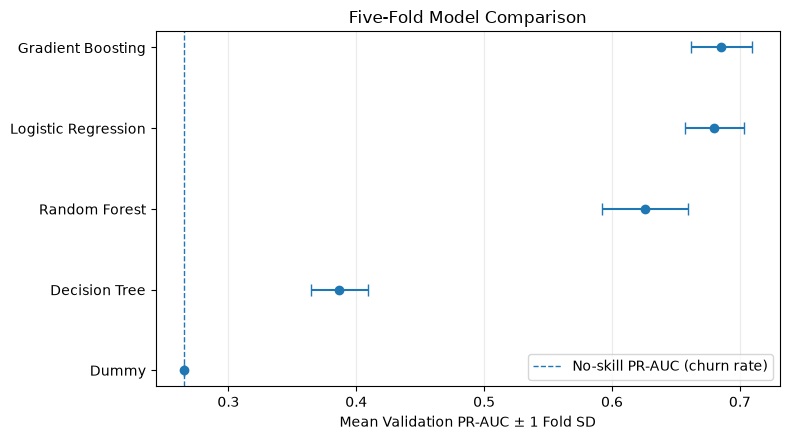

In [29]:
plot_data = model_comparison.sort_values(
    "Validation PR-AUC"
)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.errorbar(
    x=plot_data["Validation PR-AUC"],
    y=plot_data["Model"],
    xerr=plot_data["PR-AUC SD"],
    fmt="o",
    capsize=4,
)

ax.axvline(
    y_development.mean(),
    linestyle="--",
    linewidth=1,
    label="No-skill PR-AUC (churn rate)",
)

ax.set_title("Five-Fold Model Comparison")
ax.set_xlabel("Mean Validation PR-AUC ± 1 Fold SD")
ax.set_ylabel("")
ax.legend()
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "model_comparison.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

## 7. Historical Tuning and Finalist Stability

### 7.1 Historical Search Record

The initial comparison leaves logistic regression and gradient boosting as the two reasonable finalists. Logistic regression is the stronger simple baseline, while gradient boosting provides a small improvement in validation PR-AUC.

This notebook does not rerun the full historical hyperparameter searches. The searches were completed and locked during the original development workflow. Their results are documented here, and the selected parameters will be fitted again using the modern environment as a reproduction check.

Any small difference caused by newer library versions will be reported transparently. It will not be used to replace the historical winner using the already-known final test set.

In the modern scikit-learn environment, the historical L1 logistic model is implemented with `l1_ratio=1.0`, which replaces the deprecated `penalty="l1"` syntax without changing the intended regularization.

In [30]:
initial_pr_auc = (
    model_comparison
    .set_index("Model")["Validation PR-AUC"]
)

historical_tuning_record = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Gradient Boosting",
        ],
        "Initial CV PR-AUC\n(modern reproduction)": [
            initial_pr_auc["Logistic Regression"],
            initial_pr_auc["Gradient Boosting"],
        ],
        "Historical tuned\nvalidation PR-AUC": [
            0.681138,
            0.693480,
        ],
        "Historical repeated-CV\nmean PR-AUC": [
            0.680294,
            0.692413,
        ],
        "Final role": [
            "Simple finalist",
            "Locked final model",
        ],
    }
)

display(
    historical_tuning_record.style.format(
        {
            "Initial CV PR-AUC\n(modern reproduction)": "{:.6f}",
            "Historical tuned\nvalidation PR-AUC": "{:.6f}",
            "Historical repeated-CV\nmean PR-AUC": "{:.6f}",
        }
    )
)

,Model,Initial CV PR-AUC (modern reproduction),Historical tuned validation PR-AUC,Historical repeated-CV mean PR-AUC,Final role
0,Logistic Regression,0.680014,0.681138,0.680294,Simple finalist
1,Gradient Boosting,0.685420,0.693480,0.692413,Locked final model


In [31]:
# These settings were selected in the original development notebook.
# They are reproduced here rather than searched again.
HISTORICAL_LOCKED_LOGISTIC_PARAMS = {
    "C": 0.1,
    "penalty": "l1",
    "class_weight": None,
    "solver": "liblinear",
    "max_iter": 2000,
    "random_state": RANDOM_STATE,
}

# scikit-learn 1.9 represents the historical L1 choice
# with l1_ratio=1.0 instead of the deprecated penalty="l1".
MODERN_LOCKED_LOGISTIC_PARAMS = {
    "C": 0.1,
    "l1_ratio": 1.0,
    "class_weight": None,
    "solver": "liblinear",
    "max_iter": 2000,
    "random_state": RANDOM_STATE,
}


HISTORICAL_LOCKED_GRADIENT_BOOSTING_PARAMS = {
    "learning_rate": 0.025972,
    "n_estimators": 326,
    "max_depth": 3,
    "min_samples_leaf": 11,
    "subsample": 0.669982,
    "max_features": "sqrt",
    "loss": "log_loss",
    "random_state": RANDOM_STATE,
}

In [32]:
locked_parameter_rows = []

for model_name, parameters in {
    "Logistic Regression": HISTORICAL_LOCKED_LOGISTIC_PARAMS,
    "Gradient Boosting": HISTORICAL_LOCKED_GRADIENT_BOOSTING_PARAMS,
}.items():
    for parameter_name, parameter_value in parameters.items():
        locked_parameter_rows.append(
            {
                "Model": model_name,
                "Parameter": parameter_name,
                "Locked value": parameter_value,
            }
        )

locked_parameter_record = pd.DataFrame(
    locked_parameter_rows
)

display(locked_parameter_record)

,Model,Parameter,Locked value
0,Logistic Regression,C,0.1000
1,Logistic Regression,penalty,l1
2,Logistic Regression,class_weight,None
3,Logistic Regression,solver,liblinear
4,Logistic Regression,max_iter,2000
5,Logistic Regression,random_state,42
6,Gradient Boosting,learning_rate,0.0260
7,Gradient Boosting,n_estimators,326
8,Gradient Boosting,max_depth,3
9,Gradient Boosting,min_samples_leaf,11


### 7.2 Repeated-CV Stability Check

The locked logistic-regression and gradient-boosting settings are compared using ten repetitions of five-fold stratified cross-validation.

The same 50 train-validation splits are used for both models, which makes the comparison paired. Repeated cross-validation is used here to check whether the small advantage of gradient boosting is consistent across different fold assignments rather than caused by one favorable split.

This is a reproduction check under the modern environment. It does not reopen tuning or allow the known final test set to influence the model decision.

In [33]:
# Rebuild the two historical finalists with the locked settings.
locked_logistic_pipeline = Pipeline(
    steps=[
        ("preprocess", clone(linear_preprocessor)),
        (
            "model",
            LogisticRegression(
                **MODERN_LOCKED_LOGISTIC_PARAMS
            ),
        ),
    ]
)

locked_gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocess", clone(tree_preprocessor)),
        (
            "model",
            GradientBoostingClassifier(
                **HISTORICAL_LOCKED_GRADIENT_BOOSTING_PARAMS
            ),
        ),
    ]
)

locked_finalist_pipelines = {
    "Logistic Regression": locked_logistic_pipeline,
    "Gradient Boosting": locked_gradient_boosting_pipeline,
}

In [34]:
REPEATED_CV_SPLITS = 5
REPEATED_CV_REPEATS = 10

repeated_cv = RepeatedStratifiedKFold(
    n_splits=REPEATED_CV_SPLITS,
    n_repeats=REPEATED_CV_REPEATS,
    random_state=RANDOM_STATE,
)

# Store the splits once so both finalists use identical folds.
repeated_cv_splits = list(
    repeated_cv.split(
        X_development,
        y_development,
    )
)

len(repeated_cv_splits)

50

In [35]:
repeated_cv_results = {}

# Only ranking metrics are needed for this stability comparison.
for model_name, pipeline in locked_finalist_pipelines.items():
    repeated_cv_results[model_name] = cross_validate(
        estimator=pipeline,
        X=X_development,
        y=y_development,
        cv=repeated_cv_splits,
        scoring={
            "pr_auc": "average_precision",
            "roc_auc": "roc_auc",
        },
        return_train_score=True,
        n_jobs=-1,
        error_score="raise",
    )

In [36]:
historical_repeated_pr_auc = {
    "Logistic Regression": 0.680294,
    "Gradient Boosting": 0.692413,
}

finalist_summary_rows = []

for model_name, results in repeated_cv_results.items():
    validation_pr_auc = results["test_pr_auc"]
    training_pr_auc = results["train_pr_auc"]

    finalist_summary_rows.append(
        {
            "Model": model_name,
            "Modern mean PR-AUC": validation_pr_auc.mean(),
            "Modern PR-AUC SD": validation_pr_auc.std(ddof=1),
            "Modern mean ROC-AUC": results["test_roc_auc"].mean(),
            "Training PR-AUC": training_pr_auc.mean(),
            "Train-validation gap": (
                training_pr_auc.mean()
                - validation_pr_auc.mean()
            ),
            "Historical mean PR-AUC": (
                historical_repeated_pr_auc[model_name]
            ),
            "Difference from history": (
                validation_pr_auc.mean()
                - historical_repeated_pr_auc[model_name]
            ),
        }
    )

finalist_stability_summary = pd.DataFrame(
    finalist_summary_rows
)

display(
    finalist_stability_summary.style.format(
        {
            column: "{:.6f}"
            for column in finalist_stability_summary.columns
            if column != "Model"
        }
    )
)

,Model,Modern mean PR-AUC,Modern PR-AUC SD,Modern mean ROC-AUC,Training PR-AUC,Train-validation gap,Historical mean PR-AUC,Difference from history
0,Logistic Regression,0.679967,0.020362,0.857554,0.685423,0.005456,0.680294,-0.000327
1,Gradient Boosting,0.693044,0.020503,0.865285,0.729289,0.036246,0.692413,0.000631


In [37]:
logistic_pr_auc_by_repeat = (
    repeated_cv_results["Logistic Regression"]["test_pr_auc"]
    .reshape(
        REPEATED_CV_REPEATS,
        REPEATED_CV_SPLITS,
    )
    .mean(axis=1)
)

boosting_pr_auc_by_repeat = (
    repeated_cv_results["Gradient Boosting"]["test_pr_auc"]
    .reshape(
        REPEATED_CV_REPEATS,
        REPEATED_CV_SPLITS,
    )
    .mean(axis=1)
)

paired_repetition_results = pd.DataFrame(
    {
        "Repeat": range(1, REPEATED_CV_REPEATS + 1),
        "Logistic PR-AUC": logistic_pr_auc_by_repeat,
        "Gradient Boosting PR-AUC": boosting_pr_auc_by_repeat,
    }
)

paired_repetition_results["Paired difference"] = (
    paired_repetition_results["Gradient Boosting PR-AUC"]
    - paired_repetition_results["Logistic PR-AUC"]
)

paired_repetition_results["Winner"] = np.where(
    paired_repetition_results["Paired difference"] > 0,
    "Gradient Boosting",
    "Logistic Regression",
)

display(
    paired_repetition_results.style.format(
        {
            "Logistic PR-AUC": "{:.6f}",
            "Gradient Boosting PR-AUC": "{:.6f}",
            "Paired difference": "{:+.6f}",
        }
    )
)

,Repeat,Logistic PR-AUC,Gradient Boosting PR-AUC,Paired difference,Winner
0,1,0.681138,0.693733,+0.012595,Gradient Boosting
1,2,0.681183,0.695134,+0.013951,Gradient Boosting
2,3,0.680904,0.691693,+0.010790,Gradient Boosting
3,4,0.680298,0.693791,+0.013493,Gradient Boosting
4,5,0.678538,0.689354,+0.010817,Gradient Boosting
5,6,0.678033,0.693351,+0.015318,Gradient Boosting
6,7,0.679988,0.691178,+0.011190,Gradient Boosting
7,8,0.679933,0.693663,+0.013731,Gradient Boosting
8,9,0.680645,0.693837,+0.013192,Gradient Boosting
9,10,0.679014,0.694700,+0.015686,Gradient Boosting


In [38]:
paired_difference = paired_repetition_results[
    "Paired difference"
]

# Save the win counts because they are reused in the finalist decision.
boosting_wins = int((paired_difference > 0).sum())
logistic_wins = int((paired_difference < 0).sum())

repeated_cv_conclusion = pd.DataFrame(
    {
        "Check": [
            "Gradient Boosting repetition wins",
            "Logistic Regression repetition wins",
            "Mean paired PR-AUC advantage",
            "Smallest paired difference",
            "Largest paired difference",
        ],
        "Result": [
            f"{boosting_wins} of {REPEATED_CV_REPEATS}",
            f"{logistic_wins} of {REPEATED_CV_REPEATS}",
            f"{paired_difference.mean():+.6f}",
            f"{paired_difference.min():+.6f}",
            f"{paired_difference.max():+.6f}",
        ],
    }
)

display(repeated_cv_conclusion)

assert len(repeated_cv_splits) == 50
assert np.isfinite(logistic_pr_auc_by_repeat).all()
assert np.isfinite(boosting_pr_auc_by_repeat).all()

,Check,Result
0,Gradient Boosting repetition wins,10 of 10
1,Logistic Regression repetition wins,0 of 10
2,Mean paired PR-AUC advantage,+0.013076
3,Smallest paired difference,+0.010790
4,Largest paired difference,+0.015686


### 7.3 Finalist Decision

The modern repeated-CV results reproduce the main conclusion from the original development workflow.

Gradient boosting achieved a higher mean PR-AUC than logistic regression in all ten paired repetitions. The improvement is modest, but it is consistent across different fold assignments rather than depending on one favorable split.

Logistic regression remains an important simple benchmark, but the locked gradient-boosting pipeline is carried forward for out-of-fold probability generation, calibration review, and threshold selection.

No final-test information was used in the original model-selection decision. This reconstruction preserves that historical decision without reopening model selection.

In [39]:
modern_logistic_pr_auc = (
    repeated_cv_results["Logistic Regression"]["test_pr_auc"].mean()
)

modern_boosting_pr_auc = (
    repeated_cv_results["Gradient Boosting"]["test_pr_auc"].mean()
)

finalist_decision = pd.DataFrame(
    {
        "Decision item": [
            "Logistic Regression mean PR-AUC",
            "Gradient Boosting mean PR-AUC",
            "Mean paired advantage",
            "Gradient Boosting repetition wins",
            "Selected model",
        ],
        "Result": [
            f"{modern_logistic_pr_auc:.6f}",
            f"{modern_boosting_pr_auc:.6f}",
            f"{paired_difference.mean():+.6f}",
            f"{boosting_wins} of {REPEATED_CV_REPEATS}",
            "Gradient Boosting",
        ],
    }
)

display(finalist_decision)

,Decision item,Result
0,Logistic Regression mean PR-AUC,0.679967
1,Gradient Boosting mean PR-AUC,0.693044
2,Mean paired advantage,+0.013076
3,Gradient Boosting repetition wins,10 of 10
4,Selected model,Gradient Boosting


In [40]:
# Keep an unfitted copy for OOF prediction and the later final refit.
LOCKED_MODEL_NAME = "Gradient Boosting"

locked_model_pipeline = clone(
    locked_gradient_boosting_pipeline
)

## 8. Out-of-Fold Probabilities, Calibration, and Retention Policy

### 8.1 Development Out-of-Fold Probabilities

After model selection, the locked gradient-boosting pipeline is used to generate one out-of-fold probability for every development customer.

For each fold, the pipeline is trained on four-fifths of the development data and predicts probabilities for the held-out fifth. Therefore, no customer is scored by a model that was trained on that same customer.

The original five-fold split is used here rather than repeated cross-validation. Repeated cross-validation was useful for checking model stability, but it would produce multiple probabilities per customer. Threshold selection requires one clear OOF probability for each development customer.

The final test set remains unused.

In [41]:
# cross_val_predict fits a new pipeline inside each fold.
# Each development customer receives one held-out probability.
development_oof_probability_matrix = cross_val_predict(
    estimator=locked_model_pipeline,
    X=X_development,
    y=y_development,
    cv=model_cv,
    method="predict_proba",
    n_jobs=-1,
)

# The target classes are 0 and 1, so column 1 is the churn probability.
development_oof_probabilities = (
    development_oof_probability_matrix[:, 1]
)

In [42]:
development_oof_results = pd.DataFrame(
    {
        "Actual churn": y_development.to_numpy(),
        "Predicted probability": development_oof_probabilities,
    },
    index=X_development.index,
)

oof_pr_auc = average_precision_score(
    development_oof_results["Actual churn"],
    development_oof_results["Predicted probability"],
)

oof_roc_auc = roc_auc_score(
    development_oof_results["Actual churn"],
    development_oof_results["Predicted probability"],
)

In [43]:
oof_probability_summary = pd.DataFrame(
    {
        "Check": [
            "Customers scored",
            "Missing probabilities",
            "Infinite probabilities",
            "Minimum probability",
            "Maximum probability",
            "Mean predicted probability",
            "Actual churn rate",
            "OOF PR-AUC",
            "OOF ROC-AUC",
        ],
        "Result": [
            len(development_oof_results),
            development_oof_results[
                "Predicted probability"
            ].isna().sum(),
            np.isinf(
                development_oof_results[
                    "Predicted probability"
                ]
            ).sum(),
            development_oof_results[
                "Predicted probability"
            ].min(),
            development_oof_results[
                "Predicted probability"
            ].max(),
            development_oof_results[
                "Predicted probability"
            ].mean(),
            development_oof_results[
                "Actual churn"
            ].mean(),
            oof_pr_auc,
            oof_roc_auc,
        ],
    }
)

display(
    oof_probability_summary.style.format(
        {
            "Result": lambda value: (
                f"{value:.6f}"
                if isinstance(value, (float, np.floating))
                else value
            )
        }
    )
)

,Check,Result
0,Customers scored,5634.000000
1,Missing probabilities,0.000000
2,Infinite probabilities,0.000000
3,Minimum probability,0.006564
4,Maximum probability,0.931784
5,Mean predicted probability,0.265040
6,Actual churn rate,0.265353
7,OOF PR-AUC,0.690078
8,OOF ROC-AUC,0.865690


In [44]:
assert len(development_oof_results) == len(X_development)

assert development_oof_results[
    "Predicted probability"
].notna().all()

assert np.isfinite(
    development_oof_results[
        "Predicted probability"
    ]
).all()

assert development_oof_results[
    "Predicted probability"
].between(0, 1).all()

assert set(
    development_oof_results["Actual churn"].unique()
) == {0, 1}

### 8.2 Development Calibration Review

Ranking metrics and calibration answer different questions. PR-AUC and ROC-AUC measure whether the model ranks churners above non-churners, while calibration checks whether predicted probabilities match observed churn rates.

Because the retention policy uses probability thresholds and risk tiers, this review examines:

- Brier score and log loss;
- agreement between average predicted risk and actual churn prevalence;
- calibration across ten equally sized risk groups;
- calibration intercept and slope.

All calculations use development out-of-fold probabilities. The final test set remains unused.

In [45]:
# Compare the locked model with a prevalence-only probability baseline.
oof_actual = development_oof_results[
    "Actual churn"
].to_numpy()

oof_probability = development_oof_results[
    "Predicted probability"
].to_numpy()

prevalence_probability = np.full(
    shape=len(oof_actual),
    fill_value=oof_actual.mean(),
    dtype=float,
)


probability_quality = pd.DataFrame(
    {
        "Model": [
            "Locked Gradient Boosting",
            "Prevalence baseline",
        ],
        "Mean probability": [
            oof_probability.mean(),
            prevalence_probability.mean(),
        ],
        "Brier score": [
            brier_score_loss(
                oof_actual,
                oof_probability,
            ),
            brier_score_loss(
                oof_actual,
                prevalence_probability,
            ),
        ],
        "Log loss": [
            log_loss(
                oof_actual,
                oof_probability,
            ),
            log_loss(
                oof_actual,
                prevalence_probability,
            ),
        ],
        "PR-AUC": [
            average_precision_score(
                oof_actual,
                oof_probability,
            ),
            average_precision_score(
                oof_actual,
                prevalence_probability,
            ),
        ],
        "ROC-AUC": [
            roc_auc_score(
                oof_actual,
                oof_probability,
            ),
            roc_auc_score(
                oof_actual,
                prevalence_probability,
            ),
        ],
    }
)

display(
    probability_quality.style.format(
        {
            "Mean probability": "{:.6f}",
            "Brier score": "{:.6f}",
            "Log loss": "{:.6f}",
            "PR-AUC": "{:.6f}",
            "ROC-AUC": "{:.6f}",
        }
    )
)

,Model,Mean probability,Brier score,Log loss,PR-AUC,ROC-AUC
0,Locked Gradient Boosting,0.265040,0.127536,0.392234,0.690078,0.865690
1,Prevalence baseline,0.265353,0.194941,0.578582,0.265353,0.500000


In [46]:
calibration_data = development_oof_results.copy()

# Decile 1 contains the lowest predicted risks,
# while decile 10 contains the highest predicted risks.
calibration_data["Risk decile"] = (
    pd.qcut(
        calibration_data["Predicted probability"],
        q=10,
        labels=False,
        duplicates="drop",
    )
    + 1
)

calibration_deciles = (
    calibration_data
    .groupby(
        "Risk decile",
        observed=True,
    )
    .agg(
        Customers=("Actual churn", "size"),
        Mean_probability=(
            "Predicted probability",
            "mean",
        ),
        Observed_churn_rate=(
            "Actual churn",
            "mean",
        ),
    )
    .reset_index()
)

calibration_deciles["Calibration gap"] = (
    calibration_deciles["Observed_churn_rate"]
    - calibration_deciles["Mean_probability"]
)

calibration_deciles["Absolute gap"] = (
    calibration_deciles["Calibration gap"].abs()
)

display(
    calibration_deciles.style.format(
        {
            "Mean_probability": "{:.4f}",
            "Observed_churn_rate": "{:.4f}",
            "Calibration gap": "{:+.4f}",
            "Absolute gap": "{:.4f}",
        }
    )
)

,Risk decile,Customers,Mean_probability,Observed_churn_rate,Calibration gap,Absolute gap
0,1,564,0.0115,0.0018,-0.0097,0.0097
1,2,563,0.0239,0.0195,-0.0043,0.0043
2,3,563,0.0416,0.0320,-0.0096,0.0096
3,4,564,0.0730,0.0691,-0.0039,0.0039
4,5,563,0.1237,0.1385,+0.0149,0.0149
5,6,563,0.2131,0.2238,+0.0107,0.0107
6,7,564,0.3264,0.3369,+0.0105,0.0105
7,8,563,0.4552,0.4476,-0.0076,0.0076
8,9,563,0.6045,0.5968,-0.0077,0.0077
9,10,564,0.7774,0.7872,+0.0099,0.0099


In [47]:
# ECE is the customer-weighted average gap across the ten risk groups.
calibration_ece = np.average(
    calibration_deciles["Absolute gap"],
    weights=calibration_deciles["Customers"],
)

largest_decile_gap = calibration_deciles[
    "Absolute gap"
].max()


# Fit observed churn against the model's predicted log-odds.
# An ideal calibration intercept is 0 and an ideal slope is 1.
probability_for_logit = np.clip(
    oof_probability,
    1e-6,
    1 - 1e-6,
)

predicted_log_odds = np.log(
    probability_for_logit
    / (1 - probability_for_logit)
).reshape(-1, 1)

calibration_model = LogisticRegression(
    C=np.inf,
    solver="lbfgs",
    max_iter=2000,
)

calibration_model.fit(
    predicted_log_odds,
    oof_actual,
)

calibration_intercept = float(
    calibration_model.intercept_[0]
)

calibration_slope = float(
    calibration_model.coef_[0, 0]
)

In [48]:
calibration_summary = pd.DataFrame(
    {
        "Diagnostic": [
            "Actual churn rate",
            "Mean predicted probability",
            "Mean probability difference",
            "Brier score",
            "Log loss",
            "Decile ECE",
            "Largest decile gap",
            "Calibration intercept",
            "Calibration slope",
        ],
        "Result": [
            oof_actual.mean(),
            oof_probability.mean(),
            (
                oof_probability.mean()
                - oof_actual.mean()
            ),
            brier_score_loss(
                oof_actual,
                oof_probability,
            ),
            log_loss(
                oof_actual,
                oof_probability,
            ),
            calibration_ece,
            largest_decile_gap,
            calibration_intercept,
            calibration_slope,
        ],
    }
)

display(
    calibration_summary.style.format(
        {"Result": "{:.6f}"}
    )
)

assert calibration_deciles["Customers"].sum() == len(
    development_oof_results
)

assert np.isfinite(
    calibration_summary["Result"]
).all()

,Diagnostic,Result
0,Actual churn rate,0.265353
1,Mean predicted probability,0.265040
2,Mean probability difference,-0.000313
3,Brier score,0.127536
4,Log loss,0.392234
5,Decile ECE,0.008870
6,Largest decile gap,0.014892
7,Calibration intercept,0.024015
8,Calibration slope,1.037318


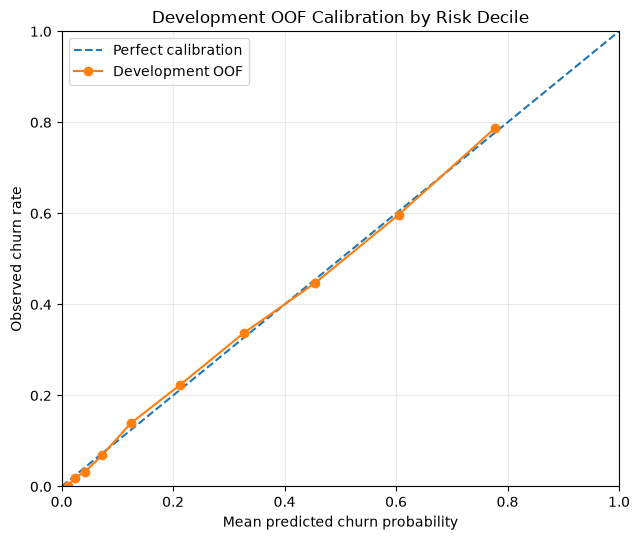

In [49]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)

ax.plot(
    calibration_deciles["Mean_probability"],
    calibration_deciles["Observed_churn_rate"],
    marker="o",
    label="Development OOF",
)

ax.set_title("Development OOF Calibration by Risk Decile")
ax.set_xlabel("Mean predicted churn probability")
ax.set_ylabel("Observed churn rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "development_oof_calibration.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

### 8.3 Calibration Decision

The locked gradient-boosting model already produces well-calibrated development out-of-fold probabilities.

The average predicted probability is almost identical to the observed churn rate, the calibration intercept is close to 0, and the calibration slope is close to 1. The decile calibration gaps are also small, and the model improves substantially over a prevalence-only probability baseline on both Brier score and log loss.

Therefore, no additional calibration layer is added. Isotonic or sigmoid calibration would increase workflow complexity without clear evidence of a meaningful probability-quality problem.

This decision is locked before threshold selection. The raw gradient-boosting probabilities will be used for the retention policy.

In [50]:
# Use simple tolerance ranges as decision evidence,
# not as universal calibration rules.
calibration_checks = {
    "Mean probability within 1 percentage point of prevalence": (
        abs(
            oof_probability.mean()
            - oof_actual.mean()
        )
        < 0.01
    ),
    "Calibration intercept close to 0": (
        abs(calibration_intercept) < 0.10
    ),
    "Calibration slope close to 1": (
        abs(calibration_slope - 1.0) < 0.10
    ),
    "Decile ECE below 2 percentage points": (
        calibration_ece < 0.02
    ),
}

calibration_decision_summary = pd.DataFrame(
    {
        "Check": calibration_checks.keys(),
        "Passed": calibration_checks.values(),
    }
)

display(calibration_decision_summary)

,Check,Passed
0,Mean probability within 1 percentage point of ...,True
1,Calibration intercept close to 0,True
2,Calibration slope close to 1,True
3,Decile ECE below 2 percentage points,True


In [51]:
CALIBRATION_METHOD = "None"

# Threshold selection will use the original OOF probabilities.
policy_oof_probabilities = oof_probability.copy()

calibration_decision = pd.DataFrame(
    {
        "Decision item": [
            "Calibration layer",
            "Probability source",
            "Reason",
        ],
        "Result": [
            CALIBRATION_METHOD,
            "Raw locked-model OOF probabilities",
            (
                "Intercept, slope, prevalence agreement, "
                "and decile calibration were all acceptable"
            ),
        ],
    }
)

display(calibration_decision)

assert all(calibration_checks.values())
assert np.array_equal(
    policy_oof_probabilities,
    oof_probability,
)

,Decision item,Result
0,Calibration layer,None
1,Probability source,Raw locked-model OOF probabilities
2,Reason,"Intercept, slope, prevalence agreement, and de..."


### 8.4 Threshold Candidate Reproduction

A probability model does not determine a business action until an operating threshold is selected.

Lower thresholds flag more customers and usually increase recall, but they also increase false positives and workload. Higher thresholds are more selective, but they miss more churners.

The main development candidates are:

- the default threshold of 0.50;
- the threshold that maximizes development OOF F1;
- thresholds that achieve at least 70%, 80%, and 90% recall.

These candidates are calculated only from development OOF probabilities. Because this notebook reconstructs an already completed workflow, the modern results are treated as a reproduction check rather than an automatic replacement for the historical locked policy.

In [52]:
precision_values, recall_values, threshold_values = (
    precision_recall_curve(
        oof_actual,
        policy_oof_probabilities,
    )
)

# The final precision and recall values do not have
# a corresponding threshold, so they are excluded here.
threshold_grid = pd.DataFrame(
    {
        "Threshold": threshold_values,
        "Precision": precision_values[:-1],
        "Recall": recall_values[:-1],
    }
)

threshold_grid["F1"] = np.where(
    (
        threshold_grid["Precision"]
        + threshold_grid["Recall"]
    )
    > 0,
    (
        2
        * threshold_grid["Precision"]
        * threshold_grid["Recall"]
        / (
            threshold_grid["Precision"]
            + threshold_grid["Recall"]
        )
    ),
    0.0,
)

threshold_grid.shape

(5564, 4)

In [53]:
def select_threshold_for_recall(
    threshold_table,
    target_recall,
):
    """Select the most precise threshold meeting a recall target."""
    eligible = threshold_table.loc[
        threshold_table["Recall"] >= target_recall
    ]

    if eligible.empty:
        raise ValueError(
            f"No threshold reaches recall {target_recall:.0%}."
        )

    return (
        eligible
        .sort_values(
            ["Precision", "Threshold"],
            ascending=[False, False],
        )
        .iloc[0]
    )


def summarize_threshold(
    rule_name,
    threshold,
):
    """Return classification and workload results for one threshold."""
    predicted_class = (
        policy_oof_probabilities >= threshold
    ).astype("int8")

    tn, fp, fn, tp = confusion_matrix(
        oof_actual,
        predicted_class,
        labels=[0, 1],
    ).ravel()

    flagged_customers = int(predicted_class.sum())

    return {
        "Rule": rule_name,
        "Threshold": threshold,
        "Flagged customers": flagged_customers,
        "Flagged rate": flagged_customers / len(oof_actual),
        "Precision": precision_score(
            oof_actual,
            predicted_class,
            zero_division=0,
        ),
        "Recall": recall_score(
            oof_actual,
            predicted_class,
            zero_division=0,
        ),
        "F1": f1_score(
            oof_actual,
            predicted_class,
            zero_division=0,
        ),
        "False positives": int(fp),
        "False negatives": int(fn),
        "True positives": int(tp),
        "True negatives": int(tn),
    }

In [54]:
maximum_f1_row = threshold_grid.loc[
    threshold_grid["F1"].idxmax()
]

recall_70_row = select_threshold_for_recall(
    threshold_grid,
    target_recall=0.70,
)

recall_80_row = select_threshold_for_recall(
    threshold_grid,
    target_recall=0.80,
)

recall_90_row = select_threshold_for_recall(
    threshold_grid,
    target_recall=0.90,
)


modern_candidate_thresholds = {
    "Default 0.50": 0.50,
    "Maximum F1": maximum_f1_row["Threshold"],
    "Recall at least 70%": recall_70_row["Threshold"],
    "Recall at least 80%": recall_80_row["Threshold"],
    "Recall at least 90%": recall_90_row["Threshold"],
}

In [55]:
threshold_candidate_rows = [
    summarize_threshold(rule_name, threshold)
    for rule_name, threshold
    in modern_candidate_thresholds.items()
]

threshold_candidate_comparison = pd.DataFrame(
    threshold_candidate_rows
)

display(
    threshold_candidate_comparison.style.format(
        {
            "Threshold": "{:.6f}",
            "Flagged rate": "{:.2%}",
            "Precision": "{:.2%}",
            "Recall": "{:.2%}",
            "F1": "{:.2%}",
        }
    )
)

,Rule,Threshold,Flagged customers,Flagged rate,Precision,Recall,F1,False positives,False negatives,True positives,True negatives
0,Default 0.50,0.500000,1239,21.99%,68.28%,56.59%,61.89%,393,649,846,3746
1,Maximum F1,0.342708,1884,33.44%,58.76%,74.05%,65.52%,777,388,1107,3362
2,Recall at least 70%,0.375953,1729,30.69%,60.67%,70.17%,65.07%,680,446,1049,3459
3,Recall at least 80%,0.286967,2169,38.50%,55.23%,80.13%,65.39%,971,297,1198,3168
4,Recall at least 90%,0.162790,2810,49.88%,47.94%,90.10%,62.58%,1463,148,1347,2676


In [56]:
historical_candidate_thresholds = {
    "Default 0.50": 0.500000,
    "Maximum F1": 0.346162,
    "Recall at least 70%": 0.372611,
    "Recall at least 80%": 0.286908,
    "Recall at least 90%": 0.165677,
}

threshold_reproduction_check = pd.DataFrame(
    {
        "Rule": modern_candidate_thresholds.keys(),
        "Modern threshold": modern_candidate_thresholds.values(),
        "Historical threshold": [
            historical_candidate_thresholds[rule]
            for rule in modern_candidate_thresholds
        ],
    }
)

threshold_reproduction_check["Difference"] = (
    threshold_reproduction_check["Modern threshold"]
    - threshold_reproduction_check["Historical threshold"]
)

display(
    threshold_reproduction_check.style.format(
        {
            "Modern threshold": "{:.6f}",
            "Historical threshold": "{:.6f}",
            "Difference": "{:+.6f}",
        }
    )
)

,Rule,Modern threshold,Historical threshold,Difference
0,Default 0.50,0.500000,0.500000,+0.000000
1,Maximum F1,0.342708,0.346162,-0.003454
2,Recall at least 70%,0.375953,0.372611,+0.003342
3,Recall at least 80%,0.286967,0.286908,+0.000059
4,Recall at least 90%,0.162790,0.165677,-0.002887


### 8.5 Locked Retention Policy

The modern threshold candidates closely reproduce the historical development results. However, this notebook is a reconstruction of an already completed workflow, so the original locked thresholds remain the official policy.

Three thresholds serve different purposes:

- the binary threshold converts churn probability into a general churn prediction;
- the priority-call threshold identifies a smaller, higher-risk group for more expensive personal outreach;
- the email threshold expands coverage through a lower-cost channel.

The model produces probabilities, while these thresholds define the business policy. Keeping the model and policy separate allows the company to change outreach capacity without retraining the model.

In [57]:
# These thresholds were selected from development OOF probabilities
# during the original locked workflow.
LOCKED_BINARY_THRESHOLD = 0.346162
LOCKED_CALL_THRESHOLD = 0.372611
LOCKED_EMAIL_THRESHOLD = 0.165677

locked_thresholds = pd.DataFrame(
    {
        "Policy rule": [
            "Binary churn prediction",
            "Priority retention call",
            "Email outreach floor",
        ],
        "Threshold": [
            LOCKED_BINARY_THRESHOLD,
            LOCKED_CALL_THRESHOLD,
            LOCKED_EMAIL_THRESHOLD,
        ],
        "Development purpose": [
            "Maximum historical OOF F1",
            "At least 70% recall with the best precision",
            "Approximately 90% cumulative churn recall",
        ],
    }
)

display(
    locked_thresholds.style.format(
        {"Threshold": "{:.6f}"}
    )
)

,Policy rule,Threshold,Development purpose
0,Binary churn prediction,0.346162,Maximum historical OOF F1
1,Priority retention call,0.372611,At least 70% recall with the best precision
2,Email outreach floor,0.165677,Approximately 90% cumulative churn recall


In [58]:
# Re-evaluate the historical thresholds using the modern OOF probabilities.
locked_threshold_results = pd.DataFrame(
    [
        summarize_threshold(
            "Binary prediction",
            LOCKED_BINARY_THRESHOLD,
        ),
        summarize_threshold(
            "Priority call or higher",
            LOCKED_CALL_THRESHOLD,
        ),
        summarize_threshold(
            "Email or higher",
            LOCKED_EMAIL_THRESHOLD,
        ),
    ]
)

display(
    locked_threshold_results.style.format(
        {
            "Threshold": "{:.6f}",
            "Flagged rate": "{:.2%}",
            "Precision": "{:.2%}",
            "Recall": "{:.2%}",
            "F1": "{:.2%}",
        }
    )
)

,Rule,Threshold,Flagged customers,Flagged rate,Precision,Recall,F1,False positives,False negatives,True positives,True negatives
0,Binary prediction,0.346162,1868,33.16%,58.89%,73.58%,65.42%,768,395,1100,3371
1,Priority call or higher,0.372611,1742,30.92%,60.56%,70.57%,65.18%,687,440,1055,3452
2,Email or higher,0.165677,2790,49.52%,48.10%,89.77%,62.64%,1448,153,1342,2691


In [59]:
# A customer receives only the highest-cost action for which they qualify.
development_policy_results = development_oof_results.copy()

development_policy_results["Action tier"] = np.select(
    [
        policy_oof_probabilities >= LOCKED_CALL_THRESHOLD,
        policy_oof_probabilities >= LOCKED_EMAIL_THRESHOLD,
    ],
    [
        "Priority retention call",
        "Email only",
    ],
    default="No immediate action",
)

action_order = [
    "Priority retention call",
    "Email only",
    "No immediate action",
]

development_policy_results["Action tier"] = pd.Categorical(
    development_policy_results["Action tier"],
    categories=action_order,
    ordered=True,
)

In [60]:
total_development_churners = int(oof_actual.sum())

development_action_summary = (
    development_policy_results
    .groupby(
        "Action tier",
        observed=False,
    )
    .agg(
        Customers=("Actual churn", "size"),
        Actual_churners=("Actual churn", "sum"),
        Mean_predicted_probability=(
            "Predicted probability",
            "mean",
        ),
        Observed_churn_rate=(
            "Actual churn",
            "mean",
        ),
    )
    .reset_index()
)

development_action_summary["Customer share"] = (
    development_action_summary["Customers"]
    / len(development_policy_results)
)

development_action_summary["Churner capture"] = (
    development_action_summary["Actual_churners"]
    / total_development_churners
)

display(
    development_action_summary.style.format(
        {
            "Mean_predicted_probability": "{:.2%}",
            "Observed_churn_rate": "{:.2%}",
            "Customer share": "{:.2%}",
            "Churner capture": "{:.2%}",
        }
    )
)

,Action tier,Customers,Actual_churners,Mean_predicted_probability,Observed_churn_rate,Customer share,Churner capture
0,Priority retention call,1742,1055,60.55%,60.56%,30.92%,70.57%
1,Email only,1048,287,26.71%,27.39%,18.60%,19.20%
2,No immediate action,2844,153,5.58%,5.38%,50.48%,10.23%


In [61]:
outreach_tiers = development_action_summary[
    "Action tier"
].isin(
    [
        "Priority retention call",
        "Email only",
    ]
)

outreach_customers = development_action_summary.loc[
    outreach_tiers,
    "Customers",
].sum()

outreach_churners = development_action_summary.loc[
    outreach_tiers,
    "Actual_churners",
].sum()

policy_coverage_summary = pd.DataFrame(
    {
        "Policy measure": [
            "Customers receiving calls or email",
            "Share of development customers contacted",
            "Churners captured by calls or email",
            "Share of development churners captured",
            "Churners receiving no immediate action",
        ],
        "Result": [
            f"{int(outreach_customers):,}",
            f"{outreach_customers / len(development_policy_results):.2%}",
            f"{int(outreach_churners):,}",
            f"{outreach_churners / total_development_churners:.2%}",
            f"{int(total_development_churners - outreach_churners):,}",
        ],
    }
)

display(policy_coverage_summary)

assert (
    development_action_summary["Customers"].sum()
    == len(development_oof_results)
)

assert (
    development_action_summary["Actual_churners"].sum()
    == total_development_churners
)

assert LOCKED_CALL_THRESHOLD > LOCKED_EMAIL_THRESHOLD

,Policy measure,Result
0,Customers receiving calls or email,"2,790"
1,Share of development customers contacted,49.52%
2,Churners captured by calls or email,"1,342"
3,Share of development churners captured,89.77%
4,Churners receiving no immediate action,153


## 9. Final Model and Test Evaluation

### 9.1 Final Refit and Historical Test-Evaluation Reproduction

The locked gradient-boosting pipeline is refitted on all 5,634 development customers and then used to score the 1,409-customer final test set that was originally reserved during development.

No model, calibration, or threshold decision will be revised after viewing these results. Because this notebook reconstructs a previously completed workflow, the test evaluation is reported as a reproduction of the original locked analysis rather than a new independent validation.

In [62]:
# Fit one fresh copy on all available development data.
final_fitted_pipeline = clone(
    locked_model_pipeline
)

final_fitted_pipeline.fit(
    X_development,
    y_development,
);

In [63]:
# Score the test set once after every development decision is locked.
test_probabilities = final_fitted_pipeline.predict_proba(
    X_test
)[:, 1]

test_binary_predictions = (
    test_probabilities >= LOCKED_BINARY_THRESHOLD
).astype("int8")

In [64]:
test_scoring_check = pd.DataFrame(
    {
        "Check": [
            "Test customers scored",
            "Missing probabilities",
            "Infinite probabilities",
            "Minimum probability",
            "Maximum probability",
            "Mean predicted probability",
            "Predicted churners at locked binary threshold",
        ],
        "Result": [
            len(test_probabilities),
            int(pd.isna(test_probabilities).sum()),
            int(np.isinf(test_probabilities).sum()),
            test_probabilities.min(),
            test_probabilities.max(),
            test_probabilities.mean(),
            int(test_binary_predictions.sum()),
        ],
    }
)

display(test_scoring_check)

assert len(test_probabilities) == len(X_test)
assert np.isfinite(test_probabilities).all()
assert np.all(
    (test_probabilities >= 0)
    & (test_probabilities <= 1)
)

,Check,Result
0,Test customers scored,"1,409.0000"
1,Missing probabilities,0.0000
2,Infinite probabilities,0.0000
3,Minimum probability,0.0066
4,Maximum probability,0.9245
5,Mean predicted probability,0.2662
6,Predicted churners at locked binary threshold,465.0000


### 9.2 Final Test Metrics and Confusion Matrix

The locked model is evaluated using the historically reserved final test set and the historical binary threshold of `0.346162`.

Ranking performance is summarized with PR-AUC and ROC-AUC. Threshold-dependent performance is summarized with precision, recall, specificity, F1, accuracy, and the confusion matrix.

Recall is interpreted together with precision and the number of customers flagged. No model or threshold decision is changed after viewing these results.

In [65]:
test_confusion_matrix = confusion_matrix(
    y_test,
    test_binary_predictions,
    labels=[0, 1],
)

tn, fp, fn, tp = test_confusion_matrix.ravel()

test_specificity = tn / (tn + fp)

final_test_metrics = pd.DataFrame(
    {
        "Metric": [
            "PR-AUC",
            "ROC-AUC",
            "Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1",
            "Brier score",
            "Log loss",
        ],
        "Result": [
            average_precision_score(
                y_test,
                test_probabilities,
            ),
            roc_auc_score(
                y_test,
                test_probabilities,
            ),
            accuracy_score(
                y_test,
                test_binary_predictions,
            ),
            precision_score(
                y_test,
                test_binary_predictions,
                zero_division=0,
            ),
            recall_score(
                y_test,
                test_binary_predictions,
                zero_division=0,
            ),
            test_specificity,
            f1_score(
                y_test,
                test_binary_predictions,
                zero_division=0,
            ),
            brier_score_loss(
                y_test,
                test_probabilities,
            ),
            log_loss(
                y_test,
                test_probabilities,
            ),
        ],
    }
)

In [66]:
display(
    final_test_metrics.style.format(
        {"Result": "{:.6f}"}
    )
)

final_confusion_counts = pd.DataFrame(
    {
        "Outcome": [
            "True negatives",
            "False positives",
            "False negatives",
            "True positives",
        ],
        "Customers": [
            tn,
            fp,
            fn,
            tp,
        ],
    }
)

display(final_confusion_counts)

,Metric,Result
0,PR-AUC,0.676037
1,ROC-AUC,0.857063
2,Accuracy,0.787793
3,Precision,0.580645
4,Recall,0.721925
5,Specificity,0.811594
6,F1,0.643623
7,Brier score,0.131898
8,Log loss,0.403211


,Outcome,Customers
0,True negatives,840
1,False positives,195
2,False negatives,104
3,True positives,270


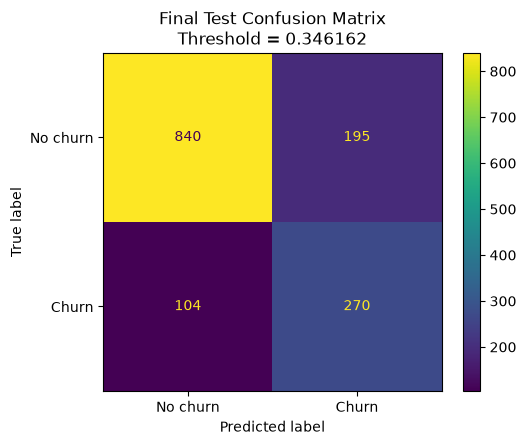

In [67]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=[
        "No churn",
        "Churn",
    ],
).plot(
    ax=ax,
    values_format="d",
)

ax.set_title(
    f"Final Test Confusion Matrix\nThreshold = {LOCKED_BINARY_THRESHOLD:.6f}"
)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "final_test_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [68]:
assert tn + fp + fn + tp == len(y_test)
assert tp + fn == int(y_test.sum())
assert tp + fp == int(test_binary_predictions.sum())

### 9.3 Development-to-Test Generalization

Development out-of-fold results are compared with final-test results to check whether model performance remained stable on unseen customers.

Small differences are expected because the two samples contain different customers. A large drop would suggest that cross-validation was overly optimistic or that the final test population differs meaningfully from the development data.

The historical threshold remains unchanged; no decision is revised after this comparison.

In [69]:
# Apply the same locked binary threshold to development OOF probabilities.
development_binary_predictions = (
    policy_oof_probabilities >= LOCKED_BINARY_THRESHOLD
).astype("int8")

development_confusion_matrix = confusion_matrix(
    oof_actual,
    development_binary_predictions,
    labels=[0, 1],
)

dev_tn, dev_fp, dev_fn, dev_tp = (
    development_confusion_matrix.ravel()
)

development_specificity = (
    dev_tn / (dev_tn + dev_fp)
)

development_metric_values = {
    "PR-AUC": average_precision_score(
        oof_actual,
        policy_oof_probabilities,
    ),
    "ROC-AUC": roc_auc_score(
        oof_actual,
        policy_oof_probabilities,
    ),
    "Accuracy": accuracy_score(
        oof_actual,
        development_binary_predictions,
    ),
    "Precision": precision_score(
        oof_actual,
        development_binary_predictions,
        zero_division=0,
    ),
    "Recall": recall_score(
        oof_actual,
        development_binary_predictions,
        zero_division=0,
    ),
    "Specificity": development_specificity,
    "F1": f1_score(
        oof_actual,
        development_binary_predictions,
        zero_division=0,
    ),
    "Brier score": brier_score_loss(
        oof_actual,
        policy_oof_probabilities,
    ),
    "Log loss": log_loss(
        oof_actual,
        policy_oof_probabilities,
    ),
}

In [70]:
test_metric_values = (
    final_test_metrics
    .set_index("Metric")["Result"]
    .to_dict()
)

development_test_comparison = pd.DataFrame(
    {
        "Metric": development_metric_values.keys(),
        "Development OOF": development_metric_values.values(),
        "Final test": [
            test_metric_values[metric]
            for metric in development_metric_values
        ],
    }
)

development_test_comparison["Test minus development"] = (
    development_test_comparison["Final test"]
    - development_test_comparison["Development OOF"]
)

display(
    development_test_comparison.style.format(
        {
            "Development OOF": "{:.6f}",
            "Final test": "{:.6f}",
            "Test minus development": "{:+.6f}",
        }
    )
)

,Metric,Development OOF,Final test,Test minus development
0,PR-AUC,0.690078,0.676037,-0.014041
1,ROC-AUC,0.865690,0.857063,-0.008627
2,Accuracy,0.793575,0.787793,-0.005782
3,Precision,0.588865,0.580645,-0.008220
4,Recall,0.735786,0.721925,-0.013861
5,Specificity,0.814448,0.811594,-0.002854
6,F1,0.654178,0.643623,-0.010554
7,Brier score,0.127536,0.131898,+0.004362
8,Log loss,0.392234,0.403211,+0.010977


In [71]:
historical_test_reference = pd.DataFrame(
    {
        "Result": [
            "PR-AUC",
            "ROC-AUC",
            "True negatives",
            "False positives",
            "False negatives",
            "True positives",
        ],
        "Modern reproduction": [
            test_metric_values["PR-AUC"],
            test_metric_values["ROC-AUC"],
            tn,
            fp,
            fn,
            tp,
        ],
        "Historical workflow": [
            0.676052,
            0.856988,
            838,
            197,
            106,
            268,
        ],
    }
)

historical_test_reference["Difference"] = (
    historical_test_reference["Modern reproduction"]
    - historical_test_reference["Historical workflow"]
)

display(historical_test_reference)

,Result,Modern reproduction,Historical workflow,Difference
0,PR-AUC,0.6760,0.6761,-0.0000
1,ROC-AUC,0.8571,0.8570,0.0001
2,True negatives,840.0000,838.0000,2.0000
3,False positives,195.0000,197.0000,-2.0000
4,False negatives,104.0000,106.0000,-2.0000
5,True positives,270.0000,268.0000,2.0000


### 9.4 Final-Test Retention Policy

The locked call and email thresholds are now applied to the final test probabilities.

Each customer receives only the highest-cost action for which they qualify:

- customers at or above the call threshold receive a priority retention call;
- customers below the call threshold but at or above the email threshold receive email outreach;
- remaining customers receive no immediate action.

These are evaluation results for the already-locked policy. The thresholds are not changed after seeing final-test outcomes.

In [72]:
# Apply the same locked business policy used in development.
test_policy_results = pd.DataFrame(
    {
        "Actual churn": y_test.to_numpy(),
        "Predicted probability": test_probabilities,
    },
    index=X_test.index,
)

test_policy_results["Action tier"] = np.select(
    [
        test_probabilities >= LOCKED_CALL_THRESHOLD,
        test_probabilities >= LOCKED_EMAIL_THRESHOLD,
    ],
    [
        "Priority retention call",
        "Email only",
    ],
    default="No immediate action",
)

test_policy_results["Action tier"] = pd.Categorical(
    test_policy_results["Action tier"],
    categories=action_order,
    ordered=True,
)

In [73]:
total_test_churners = int(y_test.sum())

final_test_action_summary = (
    test_policy_results
    .groupby(
        "Action tier",
        observed=False,
    )
    .agg(
        Customers=("Actual churn", "size"),
        Actual_churners=("Actual churn", "sum"),
        Mean_predicted_probability=(
            "Predicted probability",
            "mean",
        ),
        Observed_churn_rate=(
            "Actual churn",
            "mean",
        ),
    )
    .reset_index()
)

final_test_action_summary["Customer share"] = (
    final_test_action_summary["Customers"]
    / len(test_policy_results)
)

final_test_action_summary["Churner capture"] = (
    final_test_action_summary["Actual_churners"]
    / total_test_churners
)

display(
    final_test_action_summary.style.format(
        {
            "Mean_predicted_probability": "{:.2%}",
            "Observed_churn_rate": "{:.2%}",
            "Customer share": "{:.2%}",
            "Churner capture": "{:.2%}",
        }
    )
)

,Action tier,Customers,Actual_churners,Mean_predicted_probability,Observed_churn_rate,Customer share,Churner capture
0,Priority retention call,446,265,60.05%,59.42%,31.65%,70.86%
1,Email only,253,65,26.54%,25.69%,17.96%,17.38%
2,No immediate action,710,44,5.65%,6.20%,50.39%,11.76%


In [74]:
test_outreach_mask = final_test_action_summary[
    "Action tier"
].isin(
    [
        "Priority retention call",
        "Email only",
    ]
)

test_outreach_customers = final_test_action_summary.loc[
    test_outreach_mask,
    "Customers",
].sum()

test_outreach_churners = final_test_action_summary.loc[
    test_outreach_mask,
    "Actual_churners",
].sum()

final_test_policy_coverage = pd.DataFrame(
    {
        "Policy measure": [
            "Customers receiving calls or email",
            "Share of test customers contacted",
            "Churners captured by calls or email",
            "Share of test churners captured",
            "Churners receiving no immediate action",
        ],
        "Result": [
            f"{int(test_outreach_customers):,}",
            f"{test_outreach_customers / len(test_policy_results):.2%}",
            f"{int(test_outreach_churners):,}",
            f"{test_outreach_churners / total_test_churners:.2%}",
            f"{int(total_test_churners - test_outreach_churners):,}",
        ],
    }
)

display(final_test_policy_coverage)

,Policy measure,Result
0,Customers receiving calls or email,699
1,Share of test customers contacted,49.61%
2,Churners captured by calls or email,330
3,Share of test churners captured,88.24%
4,Churners receiving no immediate action,44


In [75]:
assert (
    final_test_action_summary["Customers"].sum()
    == len(X_test)
)

assert (
    final_test_action_summary["Actual_churners"].sum()
    == total_test_churners
)

assert test_outreach_customers <= len(X_test)
assert test_outreach_churners <= total_test_churners

### 9.5 Cumulative Churn Capture

The retention policy uses fixed probability thresholds, but the model can also support capacity-based planning.

Customers are ranked from highest to lowest predicted churn probability. The cumulative capture curve shows what share of actual churners would be reached as the company contacts a larger share of customers.

A useful model should rise above the random-contact reference line. The locked call and combined call-plus-email workloads are marked to connect ranking performance with the operating policy.

In [76]:
# Rank customers by predicted churn risk.
ranked_test_customers = (
    test_policy_results
    .sort_values(
        "Predicted probability",
        ascending=False,
    )
    .reset_index(drop=True)
)

ranked_test_customers["Customers reached"] = np.arange(
    1,
    len(ranked_test_customers) + 1,
)

ranked_test_customers["Customer share"] = (
    ranked_test_customers["Customers reached"]
    / len(ranked_test_customers)
)

ranked_test_customers["Cumulative churners captured"] = (
    ranked_test_customers["Actual churn"].cumsum()
)

ranked_test_customers["Cumulative churn capture"] = (
    ranked_test_customers["Cumulative churners captured"]
    / total_test_churners
)


call_customer_share = (
    final_test_action_summary.loc[
        final_test_action_summary["Action tier"]
        == "Priority retention call",
        "Customer share",
    ].iloc[0]
)

call_churn_capture = (
    final_test_action_summary.loc[
        final_test_action_summary["Action tier"]
        == "Priority retention call",
        "Churner capture",
    ].iloc[0]
)

outreach_customer_share = (
    test_outreach_customers / len(test_policy_results)
)

outreach_churn_capture = (
    test_outreach_churners / total_test_churners
)


assert ranked_test_customers[
    "Cumulative churners captured"
].iloc[-1] == total_test_churners

assert np.isclose(
    ranked_test_customers[
        "Cumulative churn capture"
    ].iloc[-1],
    1.0,
)

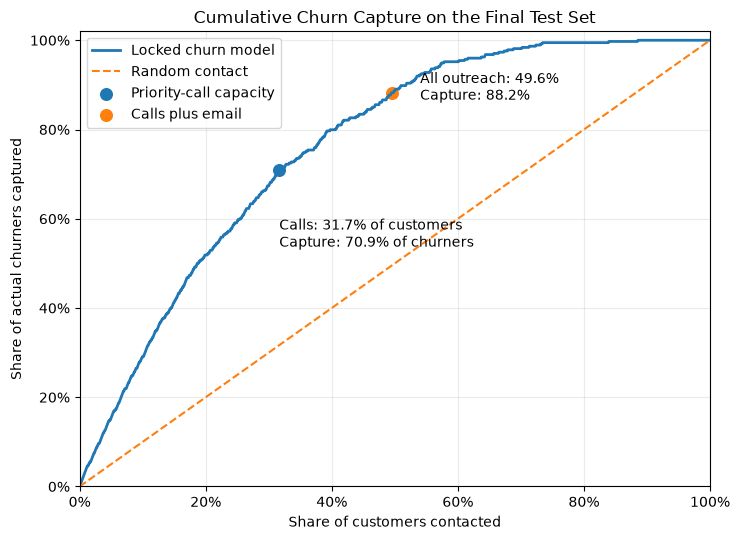

In [77]:
# Add the origin so the curve begins at 0% reached and 0% captured.
capture_curve_x = np.concatenate(
    [
        [0],
        ranked_test_customers["Customer share"].to_numpy(),
    ]
)

capture_curve_y = np.concatenate(
    [
        [0],
        ranked_test_customers[
            "Cumulative churn capture"
        ].to_numpy(),
    ]
)

fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.plot(
    capture_curve_x,
    capture_curve_y,
    linewidth=2,
    label="Locked churn model",
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random contact",
)

ax.scatter(
    call_customer_share,
    call_churn_capture,
    s=70,
    label="Priority-call capacity",
)

ax.scatter(
    outreach_customer_share,
    outreach_churn_capture,
    s=70,
    label="Calls plus email",
)

ax.annotate(
    (
        f"Calls: {call_customer_share:.1%} of customers\n"
        f"Capture: {call_churn_capture:.1%} of churners"
    ),
    xy=(call_customer_share, call_churn_capture),
    xytext=(0.08, -55),
    textcoords="offset points",
)

ax.annotate(
    (
        f"All outreach: {outreach_customer_share:.1%}\n"
        f"Capture: {outreach_churn_capture:.1%}"
    ),
    xy=(outreach_customer_share, outreach_churn_capture),
    xytext=(20, -5),
    textcoords="offset points",
)

percentage_ticks = np.linspace(0, 1, 6)

ax.set_xticks(percentage_ticks)
ax.set_xticklabels(
    [f"{value:.0%}" for value in percentage_ticks]
)

ax.set_yticks(percentage_ticks)
ax.set_yticklabels(
    [f"{value:.0%}" for value in percentage_ticks]
)

ax.set_title("Cumulative Churn Capture on the Final Test Set")
ax.set_xlabel("Share of customers contacted")
ax.set_ylabel("Share of actual churners captured")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "cumulative_churn_capture.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

### 9.6 Final-Test Calibration Check

Calibration was reviewed and locked using development out-of-fold probabilities. The final test set is now used only to check whether probability quality remained stable on unseen customers.

This post-evaluation analysis compares:

- the actual churn rate with the mean predicted probability;
- calibration across ten equally sized risk groups;
- calibration intercept and slope;
- development and final-test calibration diagnostics.

These results are descriptive only. They cannot be used to recalibrate the model, revise thresholds, or make additional model-selection decisions.

In [78]:
test_calibration_data = test_policy_results.copy()

# Decile 1 contains the lowest predicted risks,
# while decile 10 contains the highest predicted risks.
test_calibration_data["Risk decile"] = (
    pd.qcut(
        test_calibration_data["Predicted probability"],
        q=10,
        labels=False,
        duplicates="drop",
    )
    + 1
)

test_calibration_deciles = (
    test_calibration_data
    .groupby(
        "Risk decile",
        observed=True,
    )
    .agg(
        Customers=("Actual churn", "size"),
        Mean_probability=(
            "Predicted probability",
            "mean",
        ),
        Observed_churn_rate=(
            "Actual churn",
            "mean",
        ),
    )
    .reset_index()
)

test_calibration_deciles["Calibration gap"] = (
    test_calibration_deciles["Observed_churn_rate"]
    - test_calibration_deciles["Mean_probability"]
)

test_calibration_deciles["Absolute gap"] = (
    test_calibration_deciles["Calibration gap"].abs()
)

display(
    test_calibration_deciles.style.format(
        {
            "Mean_probability": "{:.4f}",
            "Observed_churn_rate": "{:.4f}",
            "Calibration gap": "{:+.4f}",
            "Absolute gap": "{:.4f}",
        }
    )
)

,Risk decile,Customers,Mean_probability,Observed_churn_rate,Calibration gap,Absolute gap
0,1,141,0.0120,0.0000,-0.0120,0.0120
1,2,141,0.0241,0.0142,-0.0100,0.0100
2,3,141,0.0426,0.0355,-0.0072,0.0072
3,4,141,0.0728,0.0780,+0.0052,0.0052
4,5,141,0.1271,0.1702,+0.0431,0.0431
5,6,140,0.2156,0.2357,+0.0201,0.0201
6,7,141,0.3308,0.3333,+0.0025,0.0025
7,8,141,0.4648,0.4113,-0.0534,0.0534
8,9,141,0.5937,0.6028,+0.0092,0.0092
9,10,141,0.7783,0.7730,-0.0053,0.0053


In [79]:
test_actual = y_test.to_numpy()

test_calibration_ece = np.average(
    test_calibration_deciles["Absolute gap"],
    weights=test_calibration_deciles["Customers"],
)

test_largest_decile_gap = (
    test_calibration_deciles["Absolute gap"].max()
)


# Estimate calibration intercept and slope from predicted log-odds.
test_probability_for_logit = np.clip(
    test_probabilities,
    1e-6,
    1 - 1e-6,
)

test_predicted_log_odds = np.log(
    test_probability_for_logit
    / (1 - test_probability_for_logit)
).reshape(-1, 1)

test_calibration_model = LogisticRegression(
    C=np.inf,
    solver="lbfgs",
    max_iter=2000,
)

test_calibration_model.fit(
    test_predicted_log_odds,
    test_actual,
)

test_calibration_intercept = float(
    test_calibration_model.intercept_[0]
)

test_calibration_slope = float(
    test_calibration_model.coef_[0, 0]
)

In [80]:
calibration_generalization = pd.DataFrame(
    {
        "Diagnostic": [
            "Actual churn rate",
            "Mean predicted probability",
            "Mean probability difference",
            "Brier score",
            "Log loss",
            "Decile ECE",
            "Largest decile gap",
            "Calibration intercept",
            "Calibration slope",
        ],
        "Development OOF": [
            oof_actual.mean(),
            oof_probability.mean(),
            oof_probability.mean() - oof_actual.mean(),
            brier_score_loss(
                oof_actual,
                oof_probability,
            ),
            log_loss(
                oof_actual,
                oof_probability,
            ),
            calibration_ece,
            largest_decile_gap,
            calibration_intercept,
            calibration_slope,
        ],
        "Final test": [
            test_actual.mean(),
            test_probabilities.mean(),
            test_probabilities.mean() - test_actual.mean(),
            brier_score_loss(
                test_actual,
                test_probabilities,
            ),
            log_loss(
                test_actual,
                test_probabilities,
            ),
            test_calibration_ece,
            test_largest_decile_gap,
            test_calibration_intercept,
            test_calibration_slope,
        ],
    }
)

calibration_generalization["Test minus development"] = (
    calibration_generalization["Final test"]
    - calibration_generalization["Development OOF"]
)

display(
    calibration_generalization.style.format(
        {
            "Development OOF": "{:.6f}",
            "Final test": "{:.6f}",
            "Test minus development": "{:+.6f}",
        }
    )
)

assert test_calibration_deciles["Customers"].sum() == len(
    y_test
)

assert np.isfinite(
    calibration_generalization[
        ["Development OOF", "Final test"]
    ].to_numpy()
).all()

,Diagnostic,Development OOF,Final test,Test minus development
0,Actual churn rate,0.265353,0.265436,+0.000083
1,Mean predicted probability,0.265040,0.266224,+0.001183
2,Mean probability difference,-0.000313,0.000787,+0.001100
3,Brier score,0.127536,0.131898,+0.004362
4,Log loss,0.392234,0.403211,+0.010977
5,Decile ECE,0.008870,0.016783,+0.007913
6,Largest decile gap,0.014892,0.053424,+0.038532
7,Calibration intercept,0.024015,-0.010970,-0.034985
8,Calibration slope,1.037318,0.991547,-0.045770


### 9.7 Final Evaluation Summary

The locked workflow generalized well to the final test set.

Ranking performance decreased modestly from development out-of-fold results, but there was no major collapse. Probability calibration also remained strong: the average predicted risk closely matched the observed churn rate, while the calibration intercept and slope stayed near their ideal values.

At the locked operating policy:

- priority calls reached about one-third of customers and captured about 71% of churners;
- calls plus email reached about half of customers and captured about 88% of churners;
- the remaining no-action group had a much lower observed churn rate.

These results describe predictive performance and operational trade-offs. They do not prove that the retention actions themselves will prevent churn.

In [81]:
final_evaluation_summary = pd.DataFrame(
    {
        "Area": [
            "Ranking",
            "Binary classification",
            "Probability quality",
            "Priority-call policy",
            "Calls plus email",
        ],
        "Final-test result": [
            (
                f"PR-AUC {test_metric_values['PR-AUC']:.3f}; "
                f"ROC-AUC {test_metric_values['ROC-AUC']:.3f}"
            ),
            (
                f"Precision {test_metric_values['Precision']:.1%}; "
                f"recall {test_metric_values['Recall']:.1%}; "
                f"{int(test_binary_predictions.sum())} customers flagged"
            ),
            (
                f"Brier {test_metric_values['Brier score']:.3f}; "
                f"calibration slope {test_calibration_slope:.3f}"
            ),
            (
                f"{int(final_test_action_summary.loc[0, 'Customers'])} customers; "
                f"{final_test_action_summary.loc[0, 'Churner capture']:.1%} "
                "of churners captured"
            ),
            (
                f"{int(test_outreach_customers)} customers; "
                f"{test_outreach_churners / total_test_churners:.1%} "
                "of churners captured"
            ),
        ],
        "Interpretation": [
            "Strong separation of higher- and lower-risk customers",
            "Useful recall with a measurable false-positive workload",
            "Predicted probabilities remained reliable on unseen customers",
            "Higher-cost outreach concentrated on the highest-risk group",
            "Lower-cost email expanded coverage substantially",
        ],
    }
)

display(final_evaluation_summary)

,Area,Final-test result,Interpretation
0,Ranking,PR-AUC 0.676; ROC-AUC 0.857,Strong separation of higher- and lower-risk cu...
1,Binary classification,Precision 58.1%; recall 72.2%; 465 customers f...,Useful recall with a measurable false-positive...
2,Probability quality,Brier 0.132; calibration slope 0.992,Predicted probabilities remained reliable on u...
3,Priority-call policy,446 customers; 70.9% of churners captured,Higher-cost outreach concentrated on the highe...
4,Calls plus email,699 customers; 88.2% of churners captured,Lower-cost email expanded coverage substantially


In [82]:
# These decisions must not change after final-test evaluation.
final_workflow_status = pd.DataFrame(
    {
        "Component": [
            "Feature contract",
            "Model",
            "Calibration layer",
            "Binary threshold",
            "Call threshold",
            "Email threshold",
            "Final-test evaluation",
        ],
        "Locked value": [
            "19 raw predictors",
            LOCKED_MODEL_NAME,
            CALIBRATION_METHOD,
            f"{LOCKED_BINARY_THRESHOLD:.6f}",
            f"{LOCKED_CALL_THRESHOLD:.6f}",
            f"{LOCKED_EMAIL_THRESHOLD:.6f}",
            "Completed once",
        ],
    }
)

display(final_workflow_status)

,Component,Locked value
0,Feature contract,19 raw predictors
1,Model,Gradient Boosting
2,Calibration layer,None
3,Binary threshold,0.346162
4,Call threshold,0.372611
5,Email threshold,0.165677
6,Final-test evaluation,Completed once


## 10. Model Interpretation

### 10.1 Final-Test Permutation Importance

Permutation importance measures how much final-test PR-AUC decreases when one raw feature is shuffled while every other feature and the fitted pipeline remain unchanged.

A larger decrease means that the model relied more heavily on that feature to preserve its ranking performance on unseen customers. Because the permutation is applied to the raw input table, categorical variables are evaluated as complete business features rather than as separate one-hot encoded columns.

This is descriptive post-evaluation analysis only. The final test set cannot be used here for feature selection, model revision, threshold changes, or additional tuning.

Importance describes predictive reliance, not direction or causality.

In [83]:
# Shuffle each raw feature 20 times and measure the PR-AUC decrease.
# The fitted model is never retrained during this analysis.
test_permutation_result = permutation_importance(
    estimator=final_fitted_pipeline,
    X=X_test,
    y=y_test,
    scoring="average_precision",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

In [84]:
permutation_importance_table = pd.DataFrame(
    {
        "Feature": X_test.columns,
        "Mean PR-AUC drop": (
            test_permutation_result.importances_mean
        ),
        "PR-AUC drop SD": (
            test_permutation_result.importances_std
        ),
        "Minimum drop": (
            test_permutation_result.importances.min(axis=1)
        ),
        "Maximum drop": (
            test_permutation_result.importances.max(axis=1)
        ),
    }
)

permutation_importance_table = (
    permutation_importance_table
    .sort_values(
        "Mean PR-AUC drop",
        ascending=False,
    )
    .reset_index(drop=True)
)

permutation_importance_table.insert(
    0,
    "Rank",
    range(1, len(permutation_importance_table) + 1),
)

In [85]:
top_permutation_features = (
    permutation_importance_table
    .head(10)
    .copy()
)

display(
    top_permutation_features.style.format(
        {
            "Mean PR-AUC drop": "{:.6f}",
            "PR-AUC drop SD": "{:.6f}",
            "Minimum drop": "{:.6f}",
            "Maximum drop": "{:.6f}",
        }
    )
)

assert len(permutation_importance_table) == len(
    MODEL_FEATURES
)

assert set(permutation_importance_table["Feature"]) == set(
    MODEL_FEATURES
)

assert np.isfinite(
    permutation_importance_table[
        [
            "Mean PR-AUC drop",
            "PR-AUC drop SD",
            "Minimum drop",
            "Maximum drop",
        ]
    ].to_numpy()
).all()

,Rank,Feature,Mean PR-AUC drop,PR-AUC drop SD,Minimum drop,Maximum drop
0,1,tenure_months,0.083660,0.010838,0.067345,0.112512
1,2,contract,0.058919,0.007523,0.043112,0.073616
2,3,dependents,0.044352,0.011943,0.026363,0.066215
3,4,total_charges,0.039102,0.008148,0.025585,0.055757
4,5,online_security,0.015499,0.004340,0.008099,0.023215
5,6,internet_service,0.013844,0.008833,0.000339,0.030690
6,7,tech_support,0.013828,0.005161,0.002857,0.022843
7,8,monthly_charges,0.010676,0.008085,-0.001037,0.030504
8,9,paperless_billing,0.009461,0.006465,-0.005071,0.021892
9,10,payment_method,0.005966,0.004830,-0.003804,0.017282


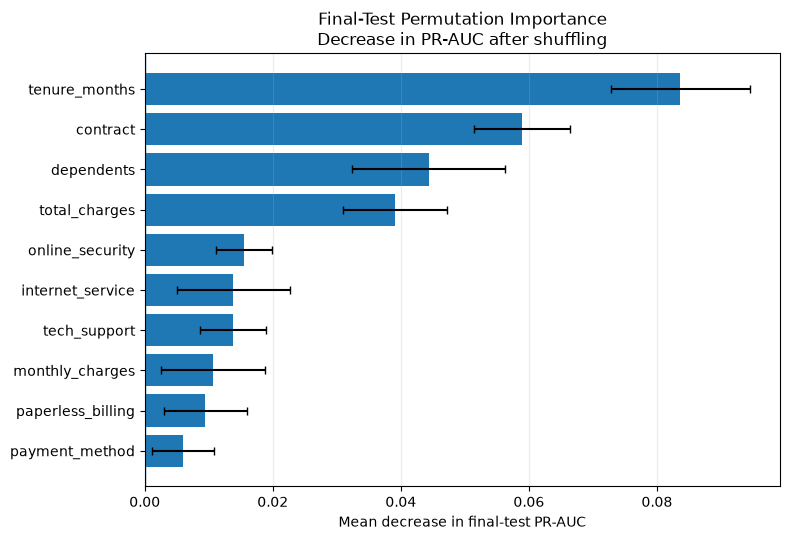

In [86]:
permutation_plot_data = (
    top_permutation_features
    .sort_values("Mean PR-AUC drop")
)

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.barh(
    permutation_plot_data["Feature"],
    permutation_plot_data["Mean PR-AUC drop"],
    xerr=permutation_plot_data["PR-AUC drop SD"],
    capsize=3,
)

ax.axvline(
    0,
    linewidth=1,
)

ax.set_title(
    "Final-Test Permutation Importance\n"
    "Decrease in PR-AUC after shuffling"
)
ax.set_xlabel("Mean decrease in final-test PR-AUC")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### 10.2 Tenure and Modeled Churn Risk

Permutation importance shows that tenure is the model's most influential raw feature, but it does not show the direction of the relationship.

Partial dependence estimates how the model's average predicted churn probability changes as `tenure_months` varies. The development customers are used as the reference population, while their other recorded features remain unchanged.

The fitted model assigns much higher average risk to newer customers, with the largest decline occurring during early tenure. The relationship becomes flatter among longer-tenure customers.

Because tenure is related to accumulated charges and other lifecycle characteristics, partial dependence may construct combinations that are uncommon in the real data. The curve should therefore be interpreted as fitted-model behavior rather than a realistic customer intervention.

This is not a causal estimate. The plot does not show what would happen if a company somehow changed a customer's tenure.

In [87]:
# Use development customers as the reference population for PDPs.
# Only the numeric dtypes change; the customer values stay the same.
X_development_interpretation = X_development.copy()

X_development_interpretation[NUMERIC_FEATURES] = (
    X_development_interpretation[NUMERIC_FEATURES]
    .astype("float64")
)

development_interpretation_dtype_check = pd.DataFrame(
    {
        "Feature": NUMERIC_FEATURES,
        "Original dtype": [
            X_development[feature].dtype
            for feature in NUMERIC_FEATURES
        ],
        "Interpretation dtype": [
            X_development_interpretation[feature].dtype
            for feature in NUMERIC_FEATURES
        ],
    }
)

display(development_interpretation_dtype_check)

,Feature,Original dtype,Interpretation dtype
0,tenure_months,int64,float64
1,monthly_charges,float64,float64
2,total_charges,Float64,float64


In [88]:
# Evaluate tenure from 1 to 72 months using 50 evenly spaced points.
tenure_evaluation_values = np.linspace(
    1.0,
    72.0,
    50,
)

tenure_partial_dependence = partial_dependence(
    estimator=final_fitted_pipeline,
    X=X_development_interpretation,
    features=["tenure_months"],
    response_method="predict_proba",
    method="brute",
    custom_values={
        "tenure_months": tenure_evaluation_values,
    },
)

tenure_grid = tenure_partial_dependence[
    "grid_values"
][0]

tenure_average_probability = tenure_partial_dependence[
    "average"
][0]

In [89]:
tenure_pdp_table = pd.DataFrame(
    {
        "Tenure months": tenure_grid,
        "Average modeled churn probability": (
            tenure_average_probability
        ),
    }
)

# Show representative points instead of all 50 rows.
tenure_pdp_preview = tenure_pdp_table.iloc[
    np.linspace(
        0,
        len(tenure_pdp_table) - 1,
        8,
        dtype=int,
    )
].reset_index(drop=True)

display(
    tenure_pdp_preview.style.format(
        {
            "Tenure months": "{:.1f}",
            "Average modeled churn probability": "{:.2%}",
        }
    )
)

assert len(tenure_pdp_table) == 50

assert np.isfinite(
    tenure_pdp_table[
        "Average modeled churn probability"
    ]
).all()

,Tenure months,Average modeled churn probability
0,1.0,37.79%
1,11.1,27.83%
2,21.3,25.47%
3,31.4,22.19%
4,41.6,22.33%
5,51.7,21.04%
6,61.9,19.11%
7,72.0,17.41%


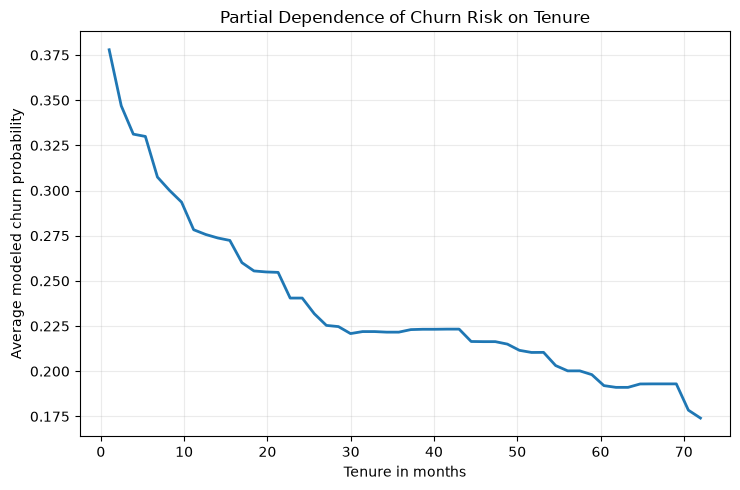

In [90]:
fig, ax = plt.subplots(figsize=(7.5, 5))

ax.plot(
    tenure_grid,
    tenure_average_probability,
    linewidth=2,
)

ax.set_title(
    "Partial Dependence of Churn Risk on Tenure"
)
ax.set_xlabel("Tenure in months")
ax.set_ylabel("Average modeled churn probability")
ax.grid(alpha=0.25)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "tenure_partial_dependence.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

### 10.3 Monthly Charges and Modeled Churn Risk

Monthly charges were also an important predictor, but their relationship with churn risk is nonlinear.

This partial-dependence profile changes `monthly_charges` across the observed development range. The development customers are used as the reference population, while their other recorded features remain unchanged.

The fitted model assigns fairly similar average churn risk across lower monthly-charge levels. Modeled risk begins increasing in the upper-middle range and rises more strongly near the highest charge levels.

Monthly charges are related to internet service, add-ons, and product bundles. Some hypothetical combinations created by partial dependence may therefore be uncommon or unrealistic.

This plot describes the fitted model's behavior. It does not prove that lowering a customer's monthly bill would prevent churn.

In [91]:
# Stay within the observed development range to avoid extrapolation.
monthly_charge_values = np.linspace(
    X_development_interpretation["monthly_charges"].min(),
    X_development_interpretation["monthly_charges"].max(),
    50,
)

monthly_charges_partial_dependence = partial_dependence(
    estimator=final_fitted_pipeline,
    X=X_development_interpretation,
    features=["monthly_charges"],
    response_method="predict_proba",
    method="brute",
    custom_values={
        "monthly_charges": monthly_charge_values,
    },
)

monthly_charges_grid = monthly_charges_partial_dependence[
    "grid_values"
][0]

monthly_charges_average_probability = (
    monthly_charges_partial_dependence["average"][0]
)

In [92]:
monthly_charges_pdp_table = pd.DataFrame(
    {
        "Monthly charges": monthly_charges_grid,
        "Average modeled churn probability": (
            monthly_charges_average_probability
        ),
    }
)

# Show a small set of values across the range.
monthly_charges_pdp_preview = monthly_charges_pdp_table.iloc[
    np.linspace(
        0,
        len(monthly_charges_pdp_table) - 1,
        8,
        dtype=int,
    )
].reset_index(drop=True)

display(
    monthly_charges_pdp_preview.style.format(
        {
            "Monthly charges": "${:.2f}",
            "Average modeled churn probability": "{:.2%}",
        }
    )
)

assert len(monthly_charges_pdp_table) == 50

assert np.isfinite(
    monthly_charges_pdp_table[
        "Average modeled churn probability"
    ]
).all()

,Monthly charges,Average modeled churn probability
0,$18.40,22.77%
1,$32.74,23.34%
2,$47.07,23.55%
3,$61.41,23.32%
4,$75.74,25.61%
5,$90.08,27.29%
6,$104.41,32.25%
7,$118.75,32.94%


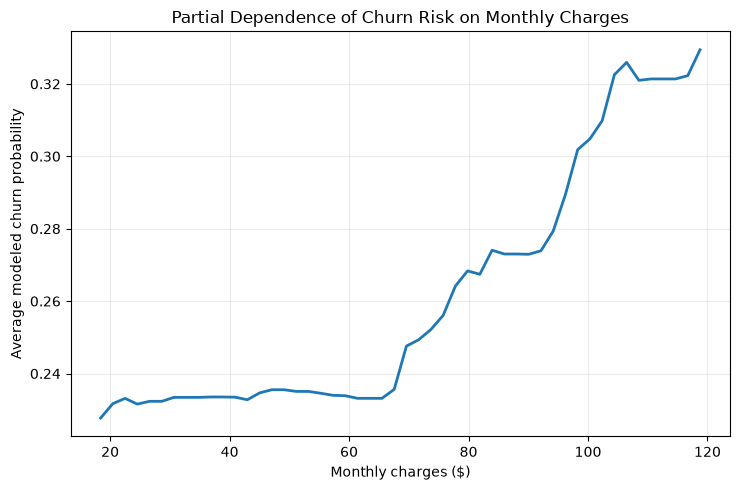

In [93]:
fig, ax = plt.subplots(figsize=(7.5, 5))

ax.plot(
    monthly_charges_grid,
    monthly_charges_average_probability,
    linewidth=2,
)

ax.set_title(
    "Partial Dependence of Churn Risk on Monthly Charges"
)
ax.set_xlabel("Monthly charges ($)")
ax.set_ylabel("Average modeled churn probability")
ax.grid(alpha=0.25)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "monthly_charges_partial_dependence.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

### 10.4 Two Local Prediction Cases

Global importance and partial-dependence plots summarize average model behavior, but individual predictions can still differ.

Two final-test examples are inspected:

- a correctly identified churner with very high predicted risk;
- a churner the model missed with a confidently low predicted probability.

These examples help show both the model's strengths and its limitations. They are descriptive post-evaluation cases only and are not used to revise the model or thresholds.

Customer identifiers are intentionally omitted from the public notebook.

In [94]:
# Combine the test features and prediction results for local inspection.
local_case_pool = X_test.copy()

local_case_pool["Actual churn"] = (
    y_test.astype("int8")
)

local_case_pool["Predicted probability"] = (
    test_probabilities
)

local_case_pool["Predicted churn"] = (
    test_binary_predictions
)

local_case_pool["Action tier"] = (
    test_policy_results["Action tier"]
    .astype(str)
)


# Choose the highest-risk true positive.
high_risk_true_positive_index = (
    local_case_pool.loc[
        (local_case_pool["Actual churn"] == 1)
        & (local_case_pool["Predicted churn"] == 1),
        "Predicted probability",
    ]
    .idxmax()
)


# Choose the lowest-risk false negative.
confident_false_negative_index = (
    local_case_pool.loc[
        (local_case_pool["Actual churn"] == 1)
        & (local_case_pool["Predicted churn"] == 0),
        "Predicted probability",
    ]
    .idxmin()
)

In [95]:
selected_local_cases = {
    "Correct high-risk churner":
        high_risk_true_positive_index,

    "Confident false negative":
        confident_false_negative_index,
}


local_case_summary_rows = []

for case_name, row_index in selected_local_cases.items():
    case_row = local_case_pool.loc[row_index]

    local_case_summary_rows.append(
        {
            "Case": case_name,
            "Actual churn": int(case_row["Actual churn"]),
            "Predicted probability": (
                case_row["Predicted probability"]
            ),
            "Binary threshold": LOCKED_BINARY_THRESHOLD,
            "Predicted churn": int(
                case_row["Predicted churn"]
            ),
            "Action tier": case_row["Action tier"],
            "Distance from threshold": (
                case_row["Predicted probability"]
                - LOCKED_BINARY_THRESHOLD
            ),
        }
    )


local_case_summary = pd.DataFrame(
    local_case_summary_rows
)

display(
    local_case_summary.style.format(
        {
            "Predicted probability": "{:.2%}",
            "Binary threshold": "{:.2%}",
            "Distance from threshold": "{:+.2%}",
        }
    )
)

,Case,Actual churn,Predicted probability,Binary threshold,Predicted churn,Action tier,Distance from threshold
0,Correct high-risk churner,1,92.45%,34.62%,1,Priority retention call,+57.83%
1,Confident false negative,1,1.93%,34.62%,0,No immediate action,-32.68%


In [96]:
# Focus on the strongest global features rather than printing
# every raw predictor for both customers.
local_profile_features = [
    "tenure_months",
    "contract",
    "dependents",
    "total_charges",
    "online_security",
    "internet_service",
    "tech_support",
    "monthly_charges",
    "payment_method",
]


local_case_profiles = pd.DataFrame(
    {
        "Feature": local_profile_features,
        "Correct high-risk churner": [
            local_case_pool.loc[
                high_risk_true_positive_index,
                feature,
            ]
            for feature in local_profile_features
        ],
        "Confident false negative": [
            local_case_pool.loc[
                confident_false_negative_index,
                feature,
            ]
            for feature in local_profile_features
        ],
    }
)

display(local_case_profiles)

,Feature,Correct high-risk churner,Confident false negative
0,tenure_months,1,72
1,contract,Month-to-month,Two year
2,dependents,No,No
3,total_charges,95.1000,"6,440.2500"
4,online_security,No,Yes
5,internet_service,Fiber optic,DSL
6,tech_support,No,Yes
7,monthly_charges,95.1000,92.4500
8,payment_method,Electronic check,Credit card (automatic)


In [97]:
assert (
    local_case_pool.loc[
        high_risk_true_positive_index,
        "Actual churn",
    ]
    == 1
)

assert (
    local_case_pool.loc[
        high_risk_true_positive_index,
        "Predicted churn",
    ]
    == 1
)

assert (
    local_case_pool.loc[
        confident_false_negative_index,
        "Actual churn",
    ]
    == 1
)

assert (
    local_case_pool.loc[
        confident_false_negative_index,
        "Predicted churn",
    ]
    == 0
)

### 10.5 Fixed-Reference Block Sensitivity

The two selected predictions are examined with a transparent reference-block replacement method.

A real development customer whose fitted probability is closest to the development average is used as one fixed reference. For each selected test case, one coherent feature block is replaced with the corresponding values from that same reference customer while all other features remain unchanged.

The local effect is calculated as:

`original probability - probability after replacing the block`

A positive value means the customer's actual block produces higher modeled risk than the reference block. A negative value means it produces lower modeled risk.

These effects are reference-dependent and nonadditive. They are local sensitivity measures, not SHAP values, causal effects, or a decomposition that must sum to the original prediction.

Replacing one block while holding all other blocks fixed may create rare or internally inconsistent customer profiles. These results should therefore be interpreted as diagnostic sensitivity comparisons, not as realistic counterfactual outcomes or causal effects.

In [98]:
# Find a real development customer with a fitted score
# closest to the average development score.
development_fitted_probabilities = (
    final_fitted_pipeline.predict_proba(
        X_development
    )[:, 1]
)

development_reference_mean = (
    development_fitted_probabilities.mean()
)

reference_position = np.abs(
    development_fitted_probabilities
    - development_reference_mean
).argmin()

reference_index = X_development.index[
    reference_position
]

reference_profile = X_development.loc[
    [reference_index],
    MODEL_FEATURES,
].copy()

reference_probability = float(
    development_fitted_probabilities[
        reference_position
    ]
)


reference_summary = pd.DataFrame(
    {
        "Reference population mean probability": [
            development_reference_mean
        ],
        "Selected reference probability": [
            reference_probability
        ],
        "Absolute difference": [
            abs(
                reference_probability
                - development_reference_mean
            )
        ],
    }
)

display(
    reference_summary.style.format(
        {
            column: "{:.4%}"
            for column in reference_summary.columns
        }
    )
)

,Reference population mean probability,Selected reference probability,Absolute difference
0,26.5153%,26.4860%,0.0292%


In [99]:
local_feature_blocks = {
    "Demographics and household": [
        "gender",
        "senior_citizen",
        "partner",
        "dependents",
    ],
    "Lifecycle and contract": [
        "tenure_months",
        "contract",
        "total_charges",
    ],
    "Phone service": [
        "phone_service",
        "multiple_lines",
    ],
    "Internet-service bundle": [
        "internet_service",
        "online_security",
        "online_backup",
        "device_protection",
        "tech_support",
        "streaming_tv",
        "streaming_movies",
    ],
    "Pricing and billing": [
        "monthly_charges",
        "paperless_billing",
        "payment_method",
    ],
}


block_design_summary = pd.DataFrame(
    {
        "Block": local_feature_blocks.keys(),
        "Features": [
            ", ".join(features)
            for features
            in local_feature_blocks.values()
        ],
        "Feature count": [
            len(features)
            for features
            in local_feature_blocks.values()
        ],
    }
)

display(block_design_summary)


# Confirm that all 19 model features appear exactly once.
covered_block_features = [
    feature
    for features in local_feature_blocks.values()
    for feature in features
]

assert len(covered_block_features) == len(
    set(covered_block_features)
)

assert set(covered_block_features) == set(
    MODEL_FEATURES
)

,Block,Features,Feature count
0,Demographics and household,"gender, senior_citizen, partner, dependents",4
1,Lifecycle and contract,"tenure_months, contract, total_charges",3
2,Phone service,"phone_service, multiple_lines",2
3,Internet-service bundle,"internet_service, online_security, online_back...",7
4,Pricing and billing,"monthly_charges, paperless_billing, payment_me...",3


In [100]:
def calculate_block_effects(
    case_name,
    row_index,
):
    """Replace one block at a time with the fixed reference block."""
    original_row = X_test.loc[
        [row_index],
        MODEL_FEATURES,
    ].copy()

    original_probability = float(
        final_fitted_pipeline.predict_proba(
            original_row
        )[0, 1]
    )

    case_records = []

    for block_name, block_features in (
        local_feature_blocks.items()
    ):
        hybrid_row = original_row.copy()

        # Replace the complete block with values from
        # the same fixed development reference customer.
        for feature in block_features:
            hybrid_row.loc[
                hybrid_row.index[0],
                feature,
            ] = reference_profile.iloc[0][feature]

        replacement_probability = float(
            final_fitted_pipeline.predict_proba(
                hybrid_row
            )[0, 1]
        )

        case_records.append(
            {
                "Case": case_name,
                "Block": block_name,
                "Original probability": (
                    original_probability
                ),
                "Probability with reference block": (
                    replacement_probability
                ),
                "Effect vs reference block": (
                    original_probability
                    - replacement_probability
                ),
            }
        )

    return case_records


local_block_records = []

for case_name, row_index in (
    selected_local_cases.items()
):
    local_block_records.extend(
        calculate_block_effects(
            case_name,
            row_index,
        )
    )

local_block_effects = pd.DataFrame(
    local_block_records
)

In [101]:
block_effect_matrix = (
    local_block_effects
    .pivot(
        index="Block",
        columns="Case",
        values="Effect vs reference block",
    )
    .reindex(local_feature_blocks.keys())
    .reset_index()
)

display(
    block_effect_matrix.style.format(
        {
            case_name: "{:+.2%}"
            for case_name in selected_local_cases
        }
    )
)

Case,Block,Confident false negative,Correct high-risk churner
0,Demographics and household,-0.02%,+1.89%
1,Lifecycle and contract,-3.57%,+53.63%
2,Phone service,-0.07%,+3.18%
3,Internet-service bundle,-2.18%,+9.25%
4,Pricing and billing,-2.87%,-1.70%


In [102]:
local_sensitivity_rows = []

for case_name in selected_local_cases:
    case_effects = local_block_effects.loc[
        local_block_effects["Case"] == case_name
    ]

    positive_effects = case_effects.loc[
        case_effects[
            "Effect vs reference block"
        ] > 0
    ]

    negative_effects = case_effects.loc[
        case_effects[
            "Effect vs reference block"
        ] < 0
    ]

    if positive_effects.empty:
        main_positive_block = "None"
        main_positive_effect = "None"
    else:
        strongest_positive = positive_effects.loc[
            positive_effects[
                "Effect vs reference block"
            ].idxmax()
        ]

        main_positive_block = strongest_positive[
            "Block"
        ]

        main_positive_effect = (
            f"{strongest_positive[
                'Effect vs reference block'
            ]:+.2%}"
        )

    if negative_effects.empty:
        main_negative_block = "None"
        main_negative_effect = "None"
    else:
        strongest_negative = negative_effects.loc[
            negative_effects[
                "Effect vs reference block"
            ].idxmin()
        ]

        main_negative_block = strongest_negative[
            "Block"
        ]

        main_negative_effect = (
            f"{strongest_negative[
                'Effect vs reference block'
            ]:+.2%}"
        )

    original_probability = case_effects[
        "Original probability"
    ].iloc[0]

    local_sensitivity_rows.append(
        {
            "Case": case_name,
            "Original probability": (
                f"{original_probability:.2%}"
            ),
            "Main risk-raising block": (
                main_positive_block
            ),
            "Risk effect": main_positive_effect,
            "Main risk-lowering block": (
                main_negative_block
            ),
            "Offset effect": main_negative_effect,
        }
    )


local_sensitivity_summary = pd.DataFrame(
    local_sensitivity_rows
)

display(local_sensitivity_summary)

,Case,Original probability,Main risk-raising block,Risk effect,Main risk-lowering block,Offset effect
0,Correct high-risk churner,92.45%,Lifecycle and contract,+53.63%,Pricing and billing,-1.70%
1,Confident false negative,1.93%,None,None,Lifecycle and contract,-3.57%


### 10.6 Interpretation Summary

The interpretation results show a consistent model story.

Tenure and contract are the strongest predictive features. The fitted model generally assigns higher risk to newer customers, especially those with month-to-month contracts. Dependents, accumulated charges, security services, technical support, internet service, and monthly charges also contribute to ranking performance.

Monthly charges have a nonlinear relationship with modeled churn risk. Average risk remains relatively stable across lower charge levels and rises more strongly near the upper range.

The local cases show both the value and limitation of the model. A short-tenure, month-to-month customer with limited support services receives a very high score, while a long-tenure customer with a two-year contract and automatic payment receives a very low score despite eventually churning.

These findings describe predictive associations and fitted-model behavior. They do not prove that changing a feature would cause churn to increase or decrease. Final-test interpretation is descriptive post-evaluation analysis and cannot be used for feature selection, model revision, or additional tuning.

## 11. Deployment and Monitoring

### 11.1 Production Architecture and Version Separation

A fitted model is not production-ready simply because it can return probabilities. A reliable scoring workflow also needs point-in-time inputs, data validation, versioned outputs, logging, and monitoring.

The intended batch-scoring flow is:

1. create a customer snapshot using information available before the retention decision;
2. validate the customer IDs, feature schema, and data quality;
3. apply the locked preprocessing and gradient-boosting pipeline;
4. produce a raw churn probability;
5. convert the probability into a binary prediction and retention action through a separate policy layer;
6. log the scoring inputs, outputs, versions, and timestamp;
7. join matured churn outcomes later for performance monitoring.

The model and policy are versioned separately because they answer different questions. The model estimates churn risk, while the policy reflects outreach cost, workload capacity, and business rules.

In [103]:
# The model version identifies the fitted probability model.
# The policy version identifies the thresholds and action rules.
MODEL_VERSION = "customer_churn_gb_v1_0_0"
POLICY_VERSION = "retention_policy_v1_0_0"


deployment_versions = pd.DataFrame(
    {
        "Component": [
            "Probability model",
            "Binary prediction rule",
            "Retention action policy",
        ],
        "Output": [
            "Predicted churn probability",
            (
                "Predicted churn class at "
                f"{LOCKED_BINARY_THRESHOLD:.6f}"
            ),
            "Priority call, email only, or no immediate action",
        ],
        "Version": [
            MODEL_VERSION,
            POLICY_VERSION,
            POLICY_VERSION,
        ],
    }
)

display(deployment_versions)

,Component,Output,Version
0,Probability model,Predicted churn probability,customer_churn_gb_v1_0_0
1,Binary prediction rule,Predicted churn class at 0.346162,retention_policy_v1_0_0
2,Retention action policy,"Priority call, email only, or no immediate action",retention_policy_v1_0_0


In [104]:
production_architecture = pd.DataFrame(
    {
        "Step": range(1, 8),
        "Production component": [
            "Point-in-time customer snapshot",
            "Input validation",
            "Locked preprocessing and model",
            "Probability output",
            "Versioned policy layer",
            "Prediction and action log",
            "Matured outcomes and monitoring",
        ],
        "Main responsibility": [
            "Use only information available before outreach",
            "Check IDs, schema, numeric validity, and data quality",
            "Apply the same transformations and fitted model",
            "Estimate each customer's churn risk",
            "Assign binary class and recommended action",
            "Preserve outputs, versions, and scoring time",
            "Evaluate drift and performance after outcomes mature",
        ],
    }
)

display(production_architecture)

,Step,Production component,Main responsibility
0,1,Point-in-time customer snapshot,Use only information available before outreach
1,2,Input validation,"Check IDs, schema, numeric validity, and data ..."
2,3,Locked preprocessing and model,Apply the same transformations and fitted model
3,4,Probability output,Estimate each customer's churn risk
4,5,Versioned policy layer,Assign binary class and recommended action
5,6,Prediction and action log,"Preserve outputs, versions, and scoring time"
6,7,Matured outcomes and monitoring,Evaluate drift and performance after outcomes ...


In [105]:
model_policy_examples = pd.DataFrame(
    {
        "Example probability": [
            0.40,
            0.35,
            0.25,
            0.10,
        ],
        "Binary class": [
            1,
            1,
            0,
            0,
        ],
        "Recommended action": [
            "Priority retention call",
            "Email only",
            "Email only",
            "No immediate action",
        ],
        "Reason": [
            "Above the call threshold",
            "Above binary threshold but below call threshold",
            "Below binary threshold but above email threshold",
            "Below the email threshold",
        ],
    }
)

display(
    model_policy_examples.style.format(
        {"Example probability": "{:.0%}"}
    )
)

,Example probability,Binary class,Recommended action,Reason
0,40%,1,Priority retention call,Above the call threshold
1,35%,1,Email only,Above binary threshold but below call threshold
2,25%,0,Email only,Below binary threshold but above email threshold
3,10%,0,No immediate action,Below the email threshold


### 11.2 Production Feature Contract

Production scoring requires one customer identifier and the same 19 raw predictors used during development.

`customer_id` is required for validation, reporting, and joining predictions back to operational systems, but it is never passed into the model. The fitted pipeline receives only the approved three numeric and sixteen categorical predictors, in the same order used during training.

Missing values are handled inside the pipeline. Previously unseen categorical values do not stop scoring because the encoder uses `handle_unknown="ignore"`, but they should still be logged because frequent new categories may indicate data drift or an upstream data problem.

Targets, post-outcome fields, and excluded variables such as `churn_score` must never appear in the model input.

In [106]:
# Read the learned categorical levels from the fitted final pipeline.
final_fitted_preprocessor = (
    final_fitted_pipeline.named_steps["preprocess"]
)

final_fitted_encoder = (
    final_fitted_preprocessor
    .named_transformers_["categorical"]
    .named_steps["onehot"]
)

known_category_map = {
    feature: [str(value) for value in categories]
    for feature, categories in zip(
        CATEGORICAL_FEATURES,
        final_fitted_encoder.categories_,
    )
}


SCORING_ID_COLUMN = ID_COLUMN

MODEL_INPUT_COLUMNS = list(MODEL_FEATURES)

REQUIRED_BATCH_COLUMNS = [
    SCORING_ID_COLUMN,
    *MODEL_INPUT_COLUMNS,
]

In [107]:
feature_contract_rows = []

for feature in NUMERIC_FEATURES:
    development_values = X_development[feature]

    feature_contract_rows.append(
        {
            "Feature": feature,
            "Feature type": "Numeric",
            "Missing-value handling": "Median imputation",
            "Known values or range": (
                f"{development_values.min():.2f} "
                f"to {development_values.max():.2f}"
            ),
        }
    )


for feature in CATEGORICAL_FEATURES:
    known_values = known_category_map[feature]

    feature_contract_rows.append(
        {
            "Feature": feature,
            "Feature type": "Categorical",
            "Missing-value handling": (
                "Constant imputation + one-hot encoding"
            ),
            "Known values or range": " | ".join(known_values),
        }
    )


production_feature_contract = pd.DataFrame(
    feature_contract_rows
)

display(production_feature_contract)

,Feature,Feature type,Missing-value handling,Known values or range
0,tenure_months,Numeric,Median imputation,0.00 to 72.00
1,monthly_charges,Numeric,Median imputation,18.40 to 118.75
2,total_charges,Numeric,Median imputation,18.85 to 8684.80
3,gender,Categorical,Constant imputation + one-hot encoding,Female | Male
4,senior_citizen,Categorical,Constant imputation + one-hot encoding,No | Yes
5,partner,Categorical,Constant imputation + one-hot encoding,No | Yes
6,dependents,Categorical,Constant imputation + one-hot encoding,No | Yes
7,phone_service,Categorical,Constant imputation + one-hot encoding,No | Yes
8,multiple_lines,Categorical,Constant imputation + one-hot encoding,No | No phone service | Yes
9,internet_service,Categorical,Constant imputation + one-hot encoding,DSL | Fiber optic | No


In [108]:
production_contract_summary = pd.DataFrame(
    {
        "Contract item": [
            "Customer identifier",
            "Numeric model features",
            "Categorical model features",
            "Total model features",
            "Unknown categorical values",
            "Excluded from model input",
        ],
        "Requirement": [
            (
                f"`{SCORING_ID_COLUMN}` must be present, "
                "non-missing, and unique"
            ),
            f"{len(NUMERIC_FEATURES)} required columns",
            f"{len(CATEGORICAL_FEATURES)} required columns",
            f"{len(MODEL_INPUT_COLUMNS)} required predictors",
            (
                "Scoring continues, but unknown values "
                "must be logged"
            ),
            (
                "Identifier, target, post-outcome fields, "
                "churn_score, geography, and CLTV"
            ),
        ],
    }
)

display(production_contract_summary)

,Contract item,Requirement
0,Customer identifier,"`customer_id` must be present, non-missing, an..."
1,Numeric model features,3 required columns
2,Categorical model features,16 required columns
3,Total model features,19 required predictors
4,Unknown categorical values,"Scoring continues, but unknown values must be ..."
5,Excluded from model input,"Identifier, target, post-outcome fields, churn..."


In [109]:
# Confirm that deployment uses the exact feature order
# learned by the fitted preprocessing pipeline.
assert list(
    final_fitted_preprocessor.feature_names_in_
) == MODEL_INPUT_COLUMNS

assert len(MODEL_INPUT_COLUMNS) == 19

assert set(MODEL_INPUT_COLUMNS) == set(
    NUMERIC_FEATURES + CATEGORICAL_FEATURES
)

assert SCORING_ID_COLUMN not in MODEL_INPUT_COLUMNS
assert TARGET_COLUMN not in MODEL_INPUT_COLUMNS
assert "churn_score" not in MODEL_INPUT_COLUMNS

assert len(known_category_map) == len(
    CATEGORICAL_FEATURES
)

### 11.3 Compact Batch Validation

Every production batch is validated before prediction.

Critical problems stop scoring:

- missing required columns;
- duplicated column names;
- missing, blank, or duplicated customer IDs;
- nonnumeric text in numeric fields;
- infinite numeric values.

Missing feature values are allowed because the fitted pipeline contains imputation. Unknown categorical values are also allowed because the encoder uses `handle_unknown="ignore"`, but both conditions are logged for monitoring.

Extra columns may remain in the operational batch, but only the approved identifier and 19 model features are carried forward.

In [110]:
def validate_scoring_batch(batch):
    """Validate one production batch and return approved scoring inputs."""
    duplicate_column_names = (
        batch.columns[batch.columns.duplicated()]
        .tolist()
    )

    if duplicate_column_names:
        raise ValueError(
            "Duplicated column names found: "
            f"{duplicate_column_names}"
        )

    missing_columns = [
        column
        for column in REQUIRED_BATCH_COLUMNS
        if column not in batch.columns
    ]

    if missing_columns:
        raise ValueError(
            "Required scoring columns are missing: "
            f"{missing_columns}"
        )

    # Ignore unrelated operational columns after recording their count.
    extra_columns = [
        column
        for column in batch.columns
        if column not in REQUIRED_BATCH_COLUMNS
    ]

    validated_batch = batch[
        REQUIRED_BATCH_COLUMNS
    ].copy()

    # Treat customer IDs as text so formatting is consistent.
    customer_id_values = (
        validated_batch[SCORING_ID_COLUMN]
        .astype("string")
        .str.strip()
    )

    missing_customer_ids = int(
        customer_id_values.isna().sum()
    )

    blank_customer_ids = int(
        customer_id_values.eq("")
        .fillna(False)
        .sum()
    )

    duplicate_customer_ids = int(
        customer_id_values.duplicated().sum()
    )

    if (
        missing_customer_ids > 0
        or blank_customer_ids > 0
        or duplicate_customer_ids > 0
    ):
        raise ValueError(
            "Customer IDs must be non-missing, non-blank, "
            "and unique within each scoring batch."
        )

    validated_batch[SCORING_ID_COLUMN] = (
        customer_id_values
    )

    invalid_numeric_values = 0
    infinite_numeric_values = 0

    # Numeric missing values are allowed, but invalid text is not.
    for feature in NUMERIC_FEATURES:
        original_values = validated_batch[feature]

        converted_values = pd.to_numeric(
            original_values,
            errors="coerce",
        )

        invalid_numeric_values += int(
            (
                original_values.notna()
                & converted_values.isna()
            ).sum()
        )

        finite_check_values = (
            converted_values
            .dropna()
            .astype("float64")
            .to_numpy()
        )

        infinite_numeric_values += int(
            np.isinf(finite_check_values).sum()
        )

        validated_batch[feature] = (
            converted_values.astype("float64")
        )

    if invalid_numeric_values > 0:
        raise ValueError(
            "At least one numeric feature contains "
            "a nonnumeric value."
        )

    if infinite_numeric_values > 0:
        raise ValueError(
            "Infinite numeric values are not allowed."
        )

    unknown_category_rows = []

    for feature in CATEGORICAL_FEATURES:
        observed_values = (
            validated_batch[feature]
            .dropna()
            .astype(str)
        )

        known_values = set(
            known_category_map[feature]
        )

        unknown_values = observed_values.loc[
            ~observed_values.isin(known_values)
        ]

        if not unknown_values.empty:
            unknown_category_rows.append(
                {
                    "Feature": feature,
                    "Unknown rows": len(unknown_values),
                    "Unknown rate": (
                        len(unknown_values)
                        / len(validated_batch)
                    ),
                    "Unknown values": " | ".join(
                        sorted(
                            unknown_values.unique()
                        )
                    ),
                }
            )

    unknown_category_log = pd.DataFrame(
        unknown_category_rows,
        columns=[
            "Feature",
            "Unknown rows",
            "Unknown rate",
            "Unknown values",
        ],
    )

    validation_summary = pd.DataFrame(
        {
            "Check": [
                "Rows received",
                "Required columns present",
                "Extra columns ignored",
                "Missing or blank customer IDs",
                "Duplicate customer IDs",
                "Invalid numeric values",
                "Infinite numeric values",
                "Numeric missing values",
                "Categorical missing values",
                "Unknown-category feature occurrences",
            ],
            "Result": [
                len(validated_batch),
                True,
                len(extra_columns),
                (
                    missing_customer_ids
                    + blank_customer_ids
                ),
                duplicate_customer_ids,
                invalid_numeric_values,
                infinite_numeric_values,
                int(
                    validated_batch[
                        NUMERIC_FEATURES
                    ].isna().sum().sum()
                ),
                int(
                    validated_batch[
                        CATEGORICAL_FEATURES
                    ].isna().sum().sum()
                ),
                (
                    int(
                        unknown_category_log[
                            "Unknown rows"
                        ].sum()
                    )
                    if not unknown_category_log.empty
                    else 0
                ),
            ],
        }
    )

    return (
        validated_batch,
        validation_summary,
        unknown_category_log,
    )

In [111]:
# Rebuild a realistic batch containing the customer ID
# and the same 19 raw predictors required in production.
production_batch_example = pd.concat(
    [
        customer_ids_test.rename(
            SCORING_ID_COLUMN
        ),
        X_test,
    ],
    axis=1,
)

production_batch_example.shape

(1409, 20)

In [112]:
(
    validated_production_batch,
    batch_validation_summary,
    unknown_category_log,
) = validate_scoring_batch(
    production_batch_example
)

display(batch_validation_summary)

if unknown_category_log.empty:
    display(
        pd.DataFrame(
            {
                "Unknown-category check": [
                    "No unknown categories detected"
                ]
            }
        )
    )
else:
    display(
        unknown_category_log.style.format(
            {"Unknown rate": "{:.2%}"}
        )
    )

,Check,Result
0,Rows received,1409
1,Required columns present,True
2,Extra columns ignored,0
3,Missing or blank customer IDs,0
4,Duplicate customer IDs,0
5,Invalid numeric values,0
6,Infinite numeric values,0
7,Numeric missing values,3
8,Categorical missing values,0
9,Unknown-category feature occurrences,0


,Unknown-category check
0,No unknown categories detected


In [113]:
validated_customer_ids = validated_production_batch[
    SCORING_ID_COLUMN
].copy()

validated_model_inputs = validated_production_batch[
    MODEL_INPUT_COLUMNS
].copy()


assert len(validated_production_batch) == len(X_test)

assert validated_customer_ids.notna().all()
assert validated_customer_ids.is_unique

assert list(
    validated_model_inputs.columns
) == MODEL_INPUT_COLUMNS

assert validated_model_inputs[
    NUMERIC_FEATURES
].apply(
    lambda column: pd.api.types.is_float_dtype(
        column
    )
).all()

### 11.4 Versioned Batch Scoring and Artifact Reproducibility

The fitted pipeline is saved as a versioned model artifact, while thresholds and action rules are stored in a separate policy file.

The saved pipeline is then reloaded and used to score the validated batch again. Its probabilities must exactly match those produced before serialization.

The scoring output includes customer identifiers for operational joining, but customer-level records are not displayed in this public notebook. Serialized model files are also treated as deployment artifacts rather than public portfolio outputs.

In [114]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

model_artifact_path = (
    ARTIFACTS_DIR / f"{MODEL_VERSION}.joblib"
)

policy_artifact_path = (
    ARTIFACTS_DIR / f"{POLICY_VERSION}.json"
)


# Save the fitted probability pipeline separately from the policy rules.
joblib.dump(
    final_fitted_pipeline,
    model_artifact_path,
)

policy_configuration = {
    "policy_version": POLICY_VERSION,
    "model_version": MODEL_VERSION,
    "binary_threshold": LOCKED_BINARY_THRESHOLD,
    "call_threshold": LOCKED_CALL_THRESHOLD,
    "email_threshold": LOCKED_EMAIL_THRESHOLD,
    "calibration_method": CALIBRATION_METHOD,
    "action_order": action_order,
}

with policy_artifact_path.open(
    "w",
    encoding="utf-8",
) as policy_file:
    json.dump(
        policy_configuration,
        policy_file,
        indent=2,
    )

In [115]:
# Score the validated inputs before and after reloading the artifact.
probabilities_before_reload = (
    final_fitted_pipeline.predict_proba(
        validated_model_inputs
    )[:, 1]
)

reloaded_pipeline = joblib.load(
    model_artifact_path
)

probabilities_after_reload = (
    reloaded_pipeline.predict_proba(
        validated_model_inputs
    )[:, 1]
)


with policy_artifact_path.open(
    "r",
    encoding="utf-8",
) as policy_file:
    reloaded_policy = json.load(policy_file)

In [116]:
maximum_probability_difference = np.max(
    np.abs(
        probabilities_before_reload
        - probabilities_after_reload
    )
)

model_artifact_sha256 = hashlib.sha256(
    model_artifact_path.read_bytes()
).hexdigest()


artifact_reproducibility = pd.DataFrame(
    {
        "Check": [
            "Model artifact exists",
            "Policy artifact exists",
            "Model version matches policy",
            "Rows reproduced",
            "Probabilities exactly identical",
            "Maximum probability difference",
            "Model artifact SHA-256 recorded",
        ],
        "Result": [
            model_artifact_path.exists(),
            policy_artifact_path.exists(),
            (
                reloaded_policy["model_version"]
                == MODEL_VERSION
            ),
            len(probabilities_after_reload),
            np.array_equal(
                probabilities_before_reload,
                probabilities_after_reload,
            ),
            maximum_probability_difference,
            bool(model_artifact_sha256),
        ],
    }
)

display(artifact_reproducibility)


assert reloaded_policy["policy_version"] == POLICY_VERSION
assert reloaded_policy["model_version"] == MODEL_VERSION

assert np.array_equal(
    probabilities_before_reload,
    probabilities_after_reload,
)

assert maximum_probability_difference == 0

,Check,Result
0,Model artifact exists,True
1,Policy artifact exists,True
2,Model version matches policy,True
3,Rows reproduced,1409
4,Probabilities exactly identical,True
5,Maximum probability difference,0.0000
6,Model artifact SHA-256 recorded,True


In [117]:
scoring_timestamp_utc = pd.Timestamp.now(
    tz="UTC"
).isoformat()

production_probabilities = (
    probabilities_after_reload
)

production_binary_predictions = (
    production_probabilities
    >= reloaded_policy["binary_threshold"]
).astype("int8")

production_actions = np.select(
    [
        production_probabilities
        >= reloaded_policy["call_threshold"],

        production_probabilities
        >= reloaded_policy["email_threshold"],
    ],
    [
        "Priority retention call",
        "Email only",
    ],
    default="No immediate action",
)


production_scoring_output = pd.DataFrame(
    {
        SCORING_ID_COLUMN: (
            validated_customer_ids.to_numpy()
        ),
        "predicted_churn_probability": (
            production_probabilities
        ),
        "predicted_churn": (
            production_binary_predictions
        ),
        "recommended_action": (
            production_actions
        ),
        "model_version": MODEL_VERSION,
        "policy_version": POLICY_VERSION,
        "scored_at_utc": scoring_timestamp_utc,
    }
)

In [118]:
production_output_summary = pd.DataFrame(
    {
        "Output check": [
            "Customers scored",
            "Predicted churners",
            "Priority retention calls",
            "Email only",
            "No immediate action",
            "Customer IDs displayed publicly",
        ],
        "Result": [
            len(production_scoring_output),
            int(
                production_scoring_output[
                    "predicted_churn"
                ].sum()
            ),
            int(
                (
                    production_scoring_output[
                        "recommended_action"
                    ]
                    == "Priority retention call"
                ).sum()
            ),
            int(
                (
                    production_scoring_output[
                        "recommended_action"
                    ]
                    == "Email only"
                ).sum()
            ),
            int(
                (
                    production_scoring_output[
                        "recommended_action"
                    ]
                    == "No immediate action"
                ).sum()
            ),
            False,
        ],
    }
)

display(production_output_summary)


assert len(production_scoring_output) == len(
    validated_production_batch
)

assert production_scoring_output[
    SCORING_ID_COLUMN
].is_unique

assert production_scoring_output[
    "predicted_churn_probability"
].between(0, 1).all()

,Output check,Result
0,Customers scored,1409
1,Predicted churners,465
2,Priority retention calls,446
3,Email only,253
4,No immediate action,710
5,Customer IDs displayed publicly,False


### 11.5 Monitoring Plan and Logging Design

Production monitoring occurs at different times.

Input quality, feature distributions, predicted probabilities, and action workload can be checked immediately after each batch is scored. Predictive performance cannot be evaluated until the churn observation window has ended and outcomes have matured.

The monitoring system therefore covers three layers:

1. input and data-quality health;
2. prediction and policy health;
3. delayed outcome performance.

An alert begins investigation. It does not automatically prove that the model failed or that retraining is required. Initial alert thresholds are operational starting points and should later be adjusted using several periods of real production history.

In [119]:
# These triggers are initial project rules, not universal standards.
monitoring_plan = pd.DataFrame(
    {
        "Monitoring area": [
            "Schema integrity",
            "Customer identity",
            "Numeric validity",
            "Missingness",
            "Unknown categories",
            "Numeric feature drift",
            "Categorical feature drift",
            "Prediction distribution",
            "Policy workload",
            "Delayed discrimination",
            "Delayed calibration",
            "Business effectiveness",
        ],
        "Timing": [
            "Every batch",
            "Every batch",
            "Every batch",
            "Every batch and monthly",
            "Every batch",
            "Monthly",
            "Monthly",
            "Weekly or monthly",
            "Every batch",
            "After outcomes mature",
            "After outcomes mature",
            "After each campaign",
        ],
        "Metric or check": [
            "Required columns",
            "Missing or duplicate IDs",
            "Nonnumeric or infinite values",
            "Change from reference missing rate",
            "Share of unseen category values",
            "Population Stability Index (PSI)",
            "Total variation distance (TVD)",
            "Mean risk and score distribution",
            "Call, email, and no-action volumes",
            "PR-AUC, ROC-AUC, precision, and recall",
            "Brier score, calibration intercept, and slope",
            "Retention lift, cost, and net benefit",
        ],
        "Initial trigger": [
            "Any required column missing",
            "Any missing or duplicate ID",
            "Any invalid numeric value",
            ">2 percentage-point increase or 2× reference",
            "Review above 1%; urgent above 5%",
            "Material distribution shift",
            "Material distribution shift",
            "Mean probability changes by more than 0.03",
            "Capacity exceeded or material rate change",
            "PR-AUC falls by more than 10%",
            "Persistent systematic probability bias",
            "Campaign net benefit fails its target",
        ],
        "Initial response": [
            "Block scoring",
            "Block scoring or resolve upstream",
            "Block the affected batch",
            "Investigate the source system",
            "Inspect mappings or product changes",
            "Investigate population or source changes",
            "Investigate category-mix changes",
            "Review inputs and workload",
            "Review policy capacity and governance",
            "Begin root-cause and retraining review",
            "Study recalibration or retraining",
            "Review the intervention, not only the model",
        ],
    }
)

display(monitoring_plan)

,Monitoring area,Timing,Metric or check,Initial trigger,Initial response
0,Schema integrity,Every batch,Required columns,Any required column missing,Block scoring
1,Customer identity,Every batch,Missing or duplicate IDs,Any missing or duplicate ID,Block scoring or resolve upstream
2,Numeric validity,Every batch,Nonnumeric or infinite values,Any invalid numeric value,Block the affected batch
3,Missingness,Every batch and monthly,Change from reference missing rate,>2 percentage-point increase or 2× reference,Investigate the source system
4,Unknown categories,Every batch,Share of unseen category values,Review above 1%; urgent above 5%,Inspect mappings or product changes
5,Numeric feature drift,Monthly,Population Stability Index (PSI),Material distribution shift,Investigate population or source changes
6,Categorical feature drift,Monthly,Total variation distance (TVD),Material distribution shift,Investigate category-mix changes
7,Prediction distribution,Weekly or monthly,Mean risk and score distribution,Mean probability changes by more than 0.03,Review inputs and workload
8,Policy workload,Every batch,"Call, email, and no-action volumes",Capacity exceeded or material rate change,Review policy capacity and governance
9,Delayed discrimination,After outcomes mature,"PR-AUC, ROC-AUC, precision, and recall",PR-AUC falls by more than 10%,Begin root-cause and retraining review


In [120]:
prediction_log_contract = pd.DataFrame(
    {
        "Log field": [
            SCORING_ID_COLUMN,
            "scored_at_utc",
            "model_version",
            "policy_version",
            "predicted_churn_probability",
            "predicted_churn",
            "recommended_action",
            "input_quality_flags",
            "action_delivered",
            "outcome_observation_date",
            "actual_churn",
        ],
        "Why it is needed": [
            "Join predictions to customers and later outcomes",
            "Preserve scoring chronology",
            "Identify the fitted model that produced the score",
            "Identify the thresholds and action rules",
            "Monitor risk-score distributions",
            "Monitor binary flagged volume",
            "Monitor operational workload",
            "Identify potentially unreliable records",
            "Separate recommendations from actual execution",
            "Confirm that the outcome window has matured",
            "Evaluate delayed predictive performance",
        ],
        "Available immediately?": [
            "Yes",
            "Yes",
            "Yes",
            "Yes",
            "Yes",
            "Yes",
            "Yes",
            "Yes",
            "After campaign execution",
            "Later",
            "Later",
        ],
    }
)

display(prediction_log_contract)

,Log field,Why it is needed,Available immediately?
0,customer_id,Join predictions to customers and later outcomes,Yes
1,scored_at_utc,Preserve scoring chronology,Yes
2,model_version,Identify the fitted model that produced the score,Yes
3,policy_version,Identify the thresholds and action rules,Yes
4,predicted_churn_probability,Monitor risk-score distributions,Yes
5,predicted_churn,Monitor binary flagged volume,Yes
6,recommended_action,Monitor operational workload,Yes
7,input_quality_flags,Identify potentially unreliable records,Yes
8,action_delivered,Separate recommendations from actual execution,After campaign execution
9,outcome_observation_date,Confirm that the outcome window has matured,Later


### 11.6 Synthetic Drift Demonstration

A monitoring system should be tested with deliberately damaged data rather than only with clean batches.

This synthetic batch introduces three controlled changes:

- monthly charges increase by 20% for every customer;
- approximately 15% of customers receive a new contract category;
- approximately 10% of previously observed `total_charges` values become missing.

The fitted model is not retrained. The purpose is to confirm that input-monitoring checks detect meaningful changes even when the prediction distribution remains relatively stable.

Population Stability Index (PSI) is used for numeric features, while Total Variation Distance (TVD) and unknown-category rate are used for categorical features. These measures detect distribution change; they do not measure predictive accuracy or automatically require retraining.

In [121]:
def make_reference_bins(values, number_of_bins=10):
    """Create fixed quantile bins from the development reference."""
    numeric_values = pd.to_numeric(
        values,
        errors="coerce",
    ).dropna()

    bin_edges = np.unique(
        numeric_values.quantile(
            np.linspace(0, 1, number_of_bins + 1)
        ).to_numpy(dtype=float)
    )

    if len(bin_edges) < 2:
        raise ValueError(
            "At least two distinct reference values are required."
        )

    # Open-ended outer bins allow future values outside
    # the original development range to be counted.
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    return bin_edges


def numeric_psi(reference_values, current_values, bin_edges):
    """Calculate PSI using fixed reference bins and a missing group."""

    def grouped_shares(values):
        numeric_values = pd.to_numeric(
            values,
            errors="coerce",
        )

        groups = (
            pd.cut(
                numeric_values,
                bins=bin_edges,
                include_lowest=True,
            )
            .astype("string")
            .fillna("Missing")
        )

        return groups.value_counts(normalize=True)

    reference_shares = grouped_shares(reference_values)
    current_shares = grouped_shares(current_values)

    all_groups = reference_shares.index.union(
        current_shares.index
    )

    small_value = 1e-6

    reference_shares = (
        reference_shares
        .reindex(all_groups, fill_value=0)
        .clip(lower=small_value)
    )

    current_shares = (
        current_shares
        .reindex(all_groups, fill_value=0)
        .clip(lower=small_value)
    )

    return float(
        (
            (current_shares - reference_shares)
            * np.log(
                current_shares / reference_shares
            )
        ).sum()
    )


def categorical_tvd(reference_values, current_values):
    """Calculate total variation distance between category shares."""
    reference_labels = (
        reference_values
        .astype("string")
        .fillna("Missing")
    )

    current_labels = (
        current_values
        .astype("string")
        .fillna("Missing")
    )

    reference_shares = reference_labels.value_counts(
        normalize=True
    )

    current_shares = current_labels.value_counts(
        normalize=True
    )

    all_categories = reference_shares.index.union(
        current_shares.index
    )

    reference_shares = reference_shares.reindex(
        all_categories,
        fill_value=0,
    )

    current_shares = current_shares.reindex(
        all_categories,
        fill_value=0,
    )

    return float(
        0.5
        * np.abs(
            current_shares - reference_shares
        ).sum()
    )


def psi_status(value):
    """Apply the initial project PSI thresholds."""
    if value >= 0.25:
        return "ALERT"
    if value >= 0.10:
        return "REVIEW"
    return "PASS"


def categorical_status(tvd, unknown_rate):
    """Use the more serious TVD or unknown-category status."""
    if tvd >= 0.20 or unknown_rate >= 0.05:
        return "ALERT"
    if tvd >= 0.10 or unknown_rate >= 0.01:
        return "REVIEW"
    return "PASS"

In [122]:
# Begin with the same valid production-shaped test batch.
synthetic_drift_batch = validated_model_inputs.copy()

rng = np.random.default_rng(RANDOM_STATE)
batch_size = len(synthetic_drift_batch)


# Simulate a broad 20% increase in monthly charges.
synthetic_drift_batch["monthly_charges"] = (
    synthetic_drift_batch["monthly_charges"] * 1.20
)


# Introduce one unseen contract category for about 15% of rows.
contract_drift_count = round(0.15 * batch_size)

contract_drift_positions = rng.choice(
    batch_size,
    size=contract_drift_count,
    replace=False,
)

synthetic_drift_batch["contract"] = (
    synthetic_drift_batch["contract"].astype("object")
)

synthetic_drift_batch.iloc[
    contract_drift_positions,
    synthetic_drift_batch.columns.get_loc("contract"),
] = "Rolling monthly"


# Add missing total charges to about 10% of rows that
# previously had an observed value.
observed_total_charge_positions = np.flatnonzero(
    synthetic_drift_batch[
        "total_charges"
    ].notna().to_numpy()
)

missingness_drift_count = round(
    0.10 * batch_size
)

missingness_drift_positions = rng.choice(
    observed_total_charge_positions,
    size=missingness_drift_count,
    replace=False,
)

synthetic_drift_batch.iloc[
    missingness_drift_positions,
    synthetic_drift_batch.columns.get_loc(
        "total_charges"
    ),
] = np.nan

In [123]:
# Use the development data as the fixed monitoring reference.
monthly_charge_bins = make_reference_bins(
    X_development["monthly_charges"]
)

total_charge_bins = make_reference_bins(
    X_development["total_charges"]
)


clean_monthly_charge_psi = numeric_psi(
    X_development["monthly_charges"],
    validated_model_inputs["monthly_charges"],
    monthly_charge_bins,
)

synthetic_monthly_charge_psi = numeric_psi(
    X_development["monthly_charges"],
    synthetic_drift_batch["monthly_charges"],
    monthly_charge_bins,
)


clean_total_charge_psi = numeric_psi(
    X_development["total_charges"],
    validated_model_inputs["total_charges"],
    total_charge_bins,
)

synthetic_total_charge_psi = numeric_psi(
    X_development["total_charges"],
    synthetic_drift_batch["total_charges"],
    total_charge_bins,
)


clean_contract_tvd = categorical_tvd(
    X_development["contract"],
    validated_model_inputs["contract"],
)

synthetic_contract_tvd = categorical_tvd(
    X_development["contract"],
    synthetic_drift_batch["contract"],
)


known_contract_values = set(
    known_category_map["contract"]
)

clean_contract_unknown_rate = (
    ~validated_model_inputs["contract"]
    .dropna()
    .astype(str)
    .isin(known_contract_values)
).sum() / len(validated_model_inputs)

synthetic_contract_unknown_rate = (
    ~synthetic_drift_batch["contract"]
    .dropna()
    .astype(str)
    .isin(known_contract_values)
).sum() / len(synthetic_drift_batch)


reference_total_charge_missing_rate = (
    X_development["total_charges"].isna().mean()
)

clean_total_charge_missing_change = (
    validated_model_inputs[
        "total_charges"
    ].isna().mean()
    - reference_total_charge_missing_rate
)

synthetic_total_charge_missing_change = (
    synthetic_drift_batch[
        "total_charges"
    ].isna().mean()
    - reference_total_charge_missing_rate
)

In [124]:
# Input drift and prediction drift are monitored separately.
reference_monitoring_probabilities = (
    final_fitted_pipeline.predict_proba(
        X_development
    )[:, 1]
)

clean_monitoring_probabilities = (
    final_fitted_pipeline.predict_proba(
        validated_model_inputs
    )[:, 1]
)

synthetic_monitoring_probabilities = (
    final_fitted_pipeline.predict_proba(
        synthetic_drift_batch
    )[:, 1]
)


score_bins = make_reference_bins(
    pd.Series(reference_monitoring_probabilities)
)

clean_score_psi = numeric_psi(
    pd.Series(reference_monitoring_probabilities),
    pd.Series(clean_monitoring_probabilities),
    score_bins,
)

synthetic_score_psi = numeric_psi(
    pd.Series(reference_monitoring_probabilities),
    pd.Series(synthetic_monitoring_probabilities),
    score_bins,
)


clean_mean_probability_shift = (
    clean_monitoring_probabilities.mean()
    - reference_monitoring_probabilities.mean()
)

synthetic_mean_probability_shift = (
    synthetic_monitoring_probabilities.mean()
    - reference_monitoring_probabilities.mean()
)

In [125]:
synthetic_monitoring_comparison = pd.DataFrame(
    {
        "Monitoring signal": [
            "Monthly charges PSI",
            "Total charges PSI",
            "Contract TVD",
            "Contract unknown-category rate",
            "Total-charges missing-rate change",
            "Mean probability shift",
            "Score-distribution PSI",
        ],
        "Clean result": [
            f"{clean_monthly_charge_psi:.4f}",
            f"{clean_total_charge_psi:.4f}",
            f"{clean_contract_tvd:.4f}",
            f"{clean_contract_unknown_rate:.2%}",
            f"{clean_total_charge_missing_change:+.2%}",
            f"{clean_mean_probability_shift:+.4f}",
            f"{clean_score_psi:.4f}",
        ],
        "Clean status": [
            psi_status(clean_monthly_charge_psi),
            psi_status(clean_total_charge_psi),
            categorical_status(
                clean_contract_tvd,
                clean_contract_unknown_rate,
            ),
            categorical_status(
                clean_contract_tvd,
                clean_contract_unknown_rate,
            ),
            (
                "ALERT"
                if clean_total_charge_missing_change > 0.02
                else "PASS"
            ),
            (
                "ALERT"
                if abs(clean_mean_probability_shift) > 0.03
                else "PASS"
            ),
            psi_status(clean_score_psi),
        ],
        "Synthetic result": [
            f"{synthetic_monthly_charge_psi:.4f}",
            f"{synthetic_total_charge_psi:.4f}",
            f"{synthetic_contract_tvd:.4f}",
            f"{synthetic_contract_unknown_rate:.2%}",
            f"{synthetic_total_charge_missing_change:+.2%}",
            f"{synthetic_mean_probability_shift:+.4f}",
            f"{synthetic_score_psi:.4f}",
        ],
        "Synthetic status": [
            psi_status(synthetic_monthly_charge_psi),
            psi_status(synthetic_total_charge_psi),
            categorical_status(
                synthetic_contract_tvd,
                synthetic_contract_unknown_rate,
            ),
            categorical_status(
                synthetic_contract_tvd,
                synthetic_contract_unknown_rate,
            ),
            (
                "ALERT"
                if synthetic_total_charge_missing_change > 0.02
                else "PASS"
            ),
            (
                "ALERT"
                if abs(synthetic_mean_probability_shift) > 0.03
                else "PASS"
            ),
            psi_status(synthetic_score_psi),
        ],
    }
)

display(synthetic_monitoring_comparison)


assert synthetic_monthly_charge_psi >= 0.25
assert synthetic_total_charge_psi >= 0.25
assert synthetic_contract_unknown_rate >= 0.05
assert synthetic_total_charge_missing_change > 0.02

,Monitoring signal,Clean result,Clean status,Synthetic result,Synthetic status
0,Monthly charges PSI,0.0129,PASS,1.4691,ALERT
1,Total charges PSI,0.0086,PASS,0.4491,ALERT
2,Contract TVD,0.0047,PASS,0.1498,ALERT
3,Contract unknown-category rate,0.00%,PASS,14.98%,ALERT
4,Total-charges missing-rate change,+0.07%,PASS,+10.08%,ALERT
5,Mean probability shift,+0.0011,PASS,+0.0084,PASS
6,Score-distribution PSI,0.0061,PASS,0.0083,PASS


### 11.7 Retraining Decisions and Deployment Summary

An alert does not automatically mean that the model should be retrained.

Schema failures, invalid values, and unexpected missingness are often data-pipeline problems that should be corrected upstream. Population drift may require investigation but not immediate retraining if model performance remains stable.

Retraining becomes more appropriate when meaningful drift persists across multiple periods, delayed predictive performance declines, calibration becomes systematically biased, or the business process and customer population have changed.

A new model must be evaluated with the same leakage controls, development-only model selection, out-of-fold threshold design, and untouched validation discipline used in the original workflow.

In [126]:
# Monitoring signals lead to different responses.
# Retraining is only one possible action.
retraining_decision_rules = pd.DataFrame(
    {
        "Observed condition": [
            "Missing required column or invalid customer IDs",
            "Invalid numeric values or sudden missingness increase",
            "New or renamed categorical values",
            "One temporary feature-distribution alert",
            "Persistent feature drift across several periods",
            "Stable inputs but changing score or action volumes",
            "Meaningful decline in delayed PR-AUC or recall",
            "Persistent calibration bias",
            "Retention campaign produces poor business value",
        ],
        "First response": [
            "Block scoring and fix the source system",
            "Investigate and correct the data pipeline",
            "Check category mappings and product definitions",
            "Investigate before changing the model",
            "Compare population, outcomes, and operating context",
            "Review policy capacity and customer mix",
            "Perform root-cause analysis and consider retraining",
            "Evaluate recalibration or model redevelopment",
            "Review the intervention and cost assumptions",
        ],
        "Retrain immediately?": [
            "No",
            "No",
            "No",
            "No",
            "Not automatically",
            "Not automatically",
            "Possibly",
            "Possibly",
            "No — model quality may not be the cause",
        ],
    }
)

display(retraining_decision_rules)

,Observed condition,First response,Retrain immediately?
0,Missing required column or invalid customer IDs,Block scoring and fix the source system,No
1,Invalid numeric values or sudden missingness i...,Investigate and correct the data pipeline,No
2,New or renamed categorical values,Check category mappings and product definitions,No
3,One temporary feature-distribution alert,Investigate before changing the model,No
4,Persistent feature drift across several periods,"Compare population, outcomes, and operating co...",Not automatically
5,Stable inputs but changing score or action vol...,Review policy capacity and customer mix,Not automatically
6,Meaningful decline in delayed PR-AUC or recall,Perform root-cause analysis and consider retra...,Possibly
7,Persistent calibration bias,Evaluate recalibration or model redevelopment,Possibly
8,Retention campaign produces poor business value,Review the intervention and cost assumptions,No — model quality may not be the cause


In [127]:
deployment_readiness_summary = pd.DataFrame(
    {
        "Deployment area": [
            "Input contract",
            "Preprocessing",
            "Batch validation",
            "Model and policy versioning",
            "Artifact reproducibility",
            "Prediction logging",
            "Immediate monitoring",
            "Delayed monitoring",
            "Drift testing",
            "Retraining governance",
        ],
        "Status": [
            "Defined",
            "Included in fitted pipeline",
            "Implemented",
            "Separated",
            "Exact reload match",
            "Specified",
            "Specified",
            "Specified",
            "Synthetic test passed",
            "Decision rules documented",
        ],
        "Evidence": [
            "Customer ID plus 19 approved predictors",
            "Imputation and encoding learned inside the pipeline",
            "Schema, IDs, numeric validity, and categories checked",
            "Probability model and retention policy have separate versions",
            "Maximum probability difference after reload was 0",
            "Probabilities, actions, versions, and timestamps retained",
            "Data quality, drift, scores, and workloads monitored",
            "PR-AUC, recall, calibration, and outcomes checked later",
            "Injected numeric, categorical, and missingness drift was detected",
            "Alerts trigger investigation rather than automatic retraining",
        ],
    }
)

display(deployment_readiness_summary)

,Deployment area,Status,Evidence
0,Input contract,Defined,Customer ID plus 19 approved predictors
1,Preprocessing,Included in fitted pipeline,Imputation and encoding learned inside the pip...
2,Batch validation,Implemented,"Schema, IDs, numeric validity, and categories ..."
3,Model and policy versioning,Separated,Probability model and retention policy have se...
4,Artifact reproducibility,Exact reload match,Maximum probability difference after reload was 0
5,Prediction logging,Specified,"Probabilities, actions, versions, and timestam..."
6,Immediate monitoring,Specified,"Data quality, drift, scores, and workloads mon..."
7,Delayed monitoring,Specified,"PR-AUC, recall, calibration, and outcomes chec..."
8,Drift testing,Synthetic test passed,"Injected numeric, categorical, and missingness..."
9,Retraining governance,Decision rules documented,Alerts trigger investigation rather than autom...


## 12. Conclusions and Portfolio Summary

### 12.1 Business Recommendations and Limitations

The model should be used to prioritize retention outreach rather than guarantee which individual customers will churn.

- **Priority calls:** Reserve personal outreach for the highest-risk tier. The 446 call-tier customers contained 70.9% of final-test churners.
- **Email outreach:** Use lower-cost email for the middle-risk tier. This added 65 churners to the outreach population.
- **Early customer experience:** Review onboarding, early service problems, and contract expectations because tenure and contract were the strongest predictive features.
- **Pricing and service value:** Investigate bill shock, promotion expiration, bundle fit, and support access because modeled risk increased across the higher monthly-charge range.
- **Intervention testing:** Use controlled experiments to determine whether calls, emails, discounts, or service changes actually reduce churn.

Important limitations:

- This notebook reconstructs a previously completed workflow; it is not a second independent validation.
- The model has not been validated on a future customer cohort or an external company.
- The dataset is a static snapshot and may omit recent complaints, outages, competitor offers, relocation, and changes in customer behavior.
- Interpretation describes predictive associations and model behavior, not causal effects.
- Thresholds depend on staffing, campaign cost, and outreach capacity.
- Future systems should record treatment assignment, delivery, and response so intervention effectiveness can be measured.

### 12.2 Final Results Summary

The table below summarizes the main technical and business results from the completed workflow.

Development cross-validation, development out-of-fold evaluation, and final-test performance are reported separately to avoid mixing different stages of model evaluation. The final-test values represent the modern reproduction of the previously locked workflow, not a second independent validation experiment.

In [128]:
# Collect the most important technical and business results
# without repeating every metric produced earlier.
final_metric_lookup = (
    final_test_metrics
    .set_index("Metric")["Result"]
    .to_dict()
)

priority_call_result = final_test_action_summary.loc[
    final_test_action_summary["Action tier"]
    == "Priority retention call"
].iloc[0]

final_results_summary = pd.DataFrame(
    {
        "Project result": [
            "Total customers",
            "Development customers",
            "Final-test customers",
            "Development churn rate",
            "Selected model",
            "Repeated-CV mean PR-AUC",
            "Development OOF PR-AUC",
            "Final-test PR-AUC",
            "Final-test ROC-AUC",
            "Final-test precision",
            "Final-test recall",
            "Final-test F1",
            "Final-test Brier score",
            "Priority-call customers",
            "Churners captured by priority calls",
            "Customers receiving calls or email",
            "Churners captured by calls or email",
        ],
        "Value": [
            f"{len(customer_data):,}",
            f"{len(X_development):,}",
            f"{len(X_test):,}",
            f"{y_development.mean():.2%}",
            LOCKED_MODEL_NAME,
            f"{modern_boosting_pr_auc:.6f}",
            f"{oof_pr_auc:.6f}",
            f"{final_metric_lookup['PR-AUC']:.6f}",
            f"{final_metric_lookup['ROC-AUC']:.6f}",
            f"{final_metric_lookup['Precision']:.2%}",
            f"{final_metric_lookup['Recall']:.2%}",
            f"{final_metric_lookup['F1']:.2%}",
            f"{final_metric_lookup['Brier score']:.6f}",
            f"{int(priority_call_result['Customers']):,}",
            f"{priority_call_result['Churner capture']:.2%}",
            f"{int(test_outreach_customers):,}",
            f"{test_outreach_churners / total_test_churners:.2%}",
        ],
        "Result type": [
            "Dataset",
            "Data split",
            "Data split",
            "Development data",
            "Locked model",
            "Repeated development CV",
            "Development OOF",
            "Final test",
            "Final test",
            "Final test at locked threshold",
            "Final test at locked threshold",
            "Final test at locked threshold",
            "Final-test probability quality",
            "Final-test business policy",
            "Final-test business policy",
            "Final-test business policy",
            "Final-test business policy",
        ],
    }
)

display(final_results_summary)

,Project result,Value,Result type
0,Total customers,"7,043",Dataset
1,Development customers,"5,634",Data split
2,Final-test customers,"1,409",Data split
3,Development churn rate,26.54%,Development data
4,Selected model,Gradient Boosting,Locked model
5,Repeated-CV mean PR-AUC,0.693044,Repeated development CV
6,Development OOF PR-AUC,0.690078,Development OOF
7,Final-test PR-AUC,0.676037,Final test
8,Final-test ROC-AUC,0.857063,Final test
9,Final-test precision,58.06%,Final test at locked threshold


### 12.3 Final Project Conclusion

This project developed a leakage-aware customer-churn workflow that converts predicted probabilities into practical retention actions.

The final gradient-boosting pipeline was selected after comparison with a strong logistic-regression baseline and stability testing across repeated cross-validation splits. Preprocessing remained inside the modeling pipelines, thresholds were selected from development out-of-fold probabilities, and the final test set was evaluated only after the model, calibration decision, and policy rules were locked.

On the 1,409-customer final test set, the modern reproduction achieved:

- **PR-AUC:** 0.676037
- **ROC-AUC:** 0.857063
- **Precision:** 58.06%
- **Recall:** 72.19%
- **F1:** 64.36%
- **True negatives / false positives / false negatives / true positives:** 840 / 195 / 104 / 270

The retention policy prioritized 446 customers for personal calls and captured 70.86% of test churners. Expanding outreach with a lower-cost email tier reached 699 customers and captured 88.24% of churners.

Interpretation showed that tenure and contract were the strongest predictive features. Partial-dependence analysis using development customers showed that modeled risk generally declined with tenure and increased nonlinearly across the higher monthly-charge range. These findings describe predictive associations and fitted-model behavior, not causal effects.

The deployment design includes a 19-feature input contract, batch validation, separate model and policy versions, reproducible serialized predictions, prediction logging, drift monitoring, delayed performance monitoring, and evidence-based retraining rules.

This notebook is a concise reconstruction of a previously completed master-reference workflow. It reproduces the original modeling decisions with modern Python and scikit-learn APIs; it is not presented as a second independent validation experiment.

The next meaningful validation step would be to evaluate the locked workflow on a genuinely new future customer cohort and measure whether the recommended retention actions produce incremental business value through a controlled experiment.